Purpose of this notebook is to test fast histogram generation tool for peak statistics analysis.

In [1]:
#Adding current repo to path because it wasn't there
import sys
import os
print(sys.path)
sys.path.append(os.path.abspath('/home/av_linux/AIRXD-CNN'))

['/root/miniconda3/envs/airxd_cnn_fresh_pyfai/lib/python311.zip', '/root/miniconda3/envs/airxd_cnn_fresh_pyfai/lib/python3.11', '/root/miniconda3/envs/airxd_cnn_fresh_pyfai/lib/python3.11/lib-dynload', '', '/root/miniconda3/envs/airxd_cnn_fresh_pyfai/lib/python3.11/site-packages', '/home/av_linux/AIRXD-ML-PUB']


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import imageio as iio
import os
from glob import glob
from airxd_cnn.poni_parse import convert_to_imctrl
import airxd_old
from airxd.mask import MASK
from airxd_cnn.transforms import powder_normalize
import importlib
import pyFAI
from scipy import ndimage
from scipy.ndimage import label
from skimage.measure import regionprops
from airxd_cnn.poni_parse import parse_poni_file, create_2theta_map_poni


# Setting up necesary functions

In [3]:
from pyFAI import load
from pyFAI.geometryRefinement import GeometryRefinement
from pyFAI.integrator.azimuthal import AzimuthalIntegrator
from pyFAI.detectors import Detector
from pyFAI.io.ponifile import PoniFile
from pyFAI.detectors.orientation import Orientation
from enum import Enum

In [4]:
class SimplifiedCalibrationModel:
    def __init__(self):
        self.detector = Detector(pixel1=79e-6, pixel2=79e-6)  # default detector
        self.pattern_geometry = None
        self.cake_geometry = None
        self.polarization_factor = 0.99
        self.correct_solid_angle = True
        self.pattern_geometry_img_shape = None
        self.orig_pixel1 = 79e-6
        self.orig_pixel2 = 79e-6
        
    def poni_flipud(self, poni_dict):
        """
        Flips the detector up-down orientation in a poni configuration dictionary.
        This is crucial for correct geometry!
        """
        if "detector_config" not in poni_dict:
            return poni_dict
            
        if "orientation" not in poni_dict["detector_config"]:
            return poni_dict
            
        orientation = poni_dict["detector_config"]["orientation"]

        print("Orientation is:", orientation)
        
        # Apply the orientation transformations as in the original code
        if orientation in (Orientation.Unspecified, Orientation.BottomRight):
            print("Flipped 1")
            poni_dict["detector_config"]["orientation"] = Orientation.TopRight
        elif orientation == Orientation.TopRight:
            print("Flipped 2")
            poni_dict["detector_config"]["orientation"] = Orientation.BottomRight
        elif orientation == Orientation.BottomLeft:
            print("Flipped 3")
            poni_dict["detector_config"]["orientation"] = Orientation.TopLeft
        elif orientation == Orientation.TopLeft:
            print("Flipped 4")
            poni_dict["detector_config"]["orientation"] = Orientation.BottomLeft
            
        return poni_dict
    
    def load_poni(self, poni_filename):
        """
        Load calibration from .poni file with proper orientation handling
        """
        # Read the poni file
        poni_dict = PoniFile(poni_filename).as_dict()
        # Critical: Apply orientation correction if needed
        if (poni_dict.get("poni_version", 1) >= 2 and 
            "detector_config" in poni_dict and
            "orientation" in poni_dict["detector_config"]):
            poni_dict = self.poni_flipud(poni_dict)

        print("Poni_dict after", poni_dict['detector_config']['orientation'])
        
        # Initialize geometry with default parameters
        self.pattern_geometry = GeometryRefinement(
            wavelength=0.3344e-10,  # default wavelength
            detector=self.detector,
            poni1=0,
            poni2=0
        )
        
        # Set the configuration from the corrected poni dictionary
        self.pattern_geometry.set_config(poni_dict)

        print(self.pattern_geometry.get_config())
        
        # Update pixel sizes from the loaded configuration
        self.orig_pixel1 = self.pattern_geometry.pixel1
        self.orig_pixel2 = self.pattern_geometry.pixel2
        
        # Update detector if it's been specified in the poni file
        if (self.pattern_geometry.pixel1 == self.detector.pixel1 and 
            self.pattern_geometry.pixel2 == self.detector.pixel2):
            self.pattern_geometry.detector = self.detector
        else:
            # Reset detector with new pixel sizes
            self.detector = Detector(
                pixel1=self.pattern_geometry.pixel1,
                pixel2=self.pattern_geometry.pixel2
            )
            self.pattern_geometry.detector = self.detector
        
        # Create cake geometry for 2D integration if needed
        self.create_cake_geometry()
        
    def create_cake_geometry(self):
        """Create azimuthal integrator for 2D integration"""
        self.cake_geometry = AzimuthalIntegrator()
        self.cake_geometry.set_config(self.pattern_geometry.get_config())
        self.cake_geometry.detector = self.detector
        
    def integrate_1d(self, img_data, num_points=None, mask=None,
                     unit="2th_deg", method="csr", azimuth_range=None, theta_range = None,
                     filename=None):
        """
        Perform 1D integration with proper setup
        """
        # Check if image shape has changed
        if self.pattern_geometry_img_shape != img_data.shape:
            self.pattern_geometry.reset()
            self.pattern_geometry_img_shape = img_data.shape
            
        # Update detector shape
        self.detector.shape = img_data.shape
        self.detector.max_shape = img_data.shape
        
        # Prepare mask
        final_mask = self._prepare_mask(mask)
        
        # Check for completely masked image
        if final_mask is not None:
            if np.sum(final_mask) == img_data.shape[0] * img_data.shape[1]:
                return np.array([]), np.array([])
        
        # Calculate number of points if not specified
        if num_points is None:
            num_points = self._calculate_num_points(img_data.shape)
        
        # Perform integration
        if unit == "d_A":
            # Special handling for d-spacing
            tth, intensity = self.pattern_geometry.integrate1d(
                img_data,
                num_points,
                method=method,
                unit="2th_deg",
                azimuth_range=azimuth_range,
                mask=final_mask,
                polarization_factor=self.polarization_factor,
                correctSolidAngle=self.correct_solid_angle,
                filename=filename
            )
            # Convert to d-spacing
            wavelength_angstrom = self.pattern_geometry.wavelength * 1e10
            tth = wavelength_angstrom / (2 * np.sin(np.radians(tth) / 2))
        else:
            tth, intensity = self.pattern_geometry.integrate1d(
                img_data,
                num_points,
                method=method,
                unit=unit,
                azimuth_range=azimuth_range,
                radial_range = theta_range,
                mask=final_mask,
                polarization_factor=self.polarization_factor,
                correctSolidAngle=self.correct_solid_angle,
                filename=filename
            )
            
        return tth, intensity
    
    def _calculate_num_points(self, img_shape):
        """Calculate number of points based on image geometry"""
        # Following the original implementation
        fit2d_params = self.pattern_geometry.getFit2D()
        center_x = fit2d_params["centerX"]
        center_y = fit2d_params["centerY"]
        width, height = img_shape
        
        if 0 < center_x < width:
            side1 = max(abs(width - center_x), center_x)
        else:
            side1 = width
            
        if 0 < center_y < height:
            side2 = max(abs(height - center_y), center_y)
        else:
            side2 = height
            
        max_dist = np.sqrt(side1**2 + side2**2)
        return int(max_dist * 1.5)  # 1.5 is the max_dist_factor
    
    def _prepare_mask(self, user_mask):
        """Prepare integration mask combining user and detector masks"""
        detector_mask = None
        
        # Check for detector mask
        if hasattr(self.detector, 'mask') and self.detector.mask is not None:
            detector_mask = self.detector.mask
        elif hasattr(self.detector, 'calc_mask'):
            self.detector.calc_mask()
            if hasattr(self.detector, 'mask'):
                detector_mask = self.detector.mask
                
        # Combine masks
        if user_mask is None:
            return detector_mask
        elif detector_mask is None:
            return user_mask
        else:
            if user_mask.shape == detector_mask.shape:
                return np.logical_or(user_mask, detector_mask)
            else:
                return user_mask

# Usage example
def process_with_proper_orientation(image_path, poni_path):
    """Process image with correct orientation handling"""
    import fabio
    
    # Load image
    img = fabio.open(image_path)
    img_data = img.data
    
    # Initialize model
    cal = SimplifiedCalibrationModel()
    
    # Load calibration with orientation correction
    cal.load_poni(poni_path)
    
    # Perform integration
    tth, intensity = cal.integrate_1d(
        img_data,
        num_points=None,  # Auto-calculate
        method="csr",
        unit="2th_deg"
    )
    
    return tth, intensity

In [5]:
def filter_connected_components_by_size(mask, min_size, max_size=None):
    """
    Filters connected components in the mask based on size.
    
    Parameters:
        mask (ndarray): Binary mask where spots are marked as 1, and the background is 0.
        min_size (int): Minimum number of pixels for a connected component to be kept.
        max_size (int, optional): Maximum number of pixels for a connected component to be kept. If None, no upper limit.
        
    Returns:
        filtered_mask (ndarray): Mask with only the connected components that meet the size criteria.
    """
    # Label each connected component in the binary mask
    labeled_mask, _ = label(mask)
    
    # Initialize an empty mask to hold the filtered components
    filtered_mask = np.zeros_like(mask)
    
    # Get properties of labeled regions
    regions = regionprops(labeled_mask)
    
    for region in regions:
        # Check the size of each region
        region_size = region.area
        if region_size >= min_size and (max_size is None or region_size <= max_size):
            # Add this region to the filtered mask
            filtered_mask[labeled_mask == region.label] = 1
    
    return filtered_mask

In [6]:
#Directory info
#----------------
example_im_dir = '../data/from_martin/Texture_Examples/Shanece/'
example_im_files = glob(example_im_dir + '*.tiff')
example_im_files.sort()
print(example_im_files)

#Masking
#----------------
idx = 1
im = iio.v2.volread(example_im_files[idx])
#Note to future self. Do NOT normalize the images before using median finder or else it simply won't work.
normalized_im = powder_normalize(im)

#Mask


['../data/from_martin/Texture_Examples/Shanece/LaB6Shanece.tiff', '../data/from_martin/Texture_Examples/Shanece/Shanece.tiff']


In [7]:
def create_circular_mask(height, width, radius):
    """
    Creates a mask with a circle of 1's at the center and 0's elsewhere.
    
    Parameters:
    -----------
    height : int
        Height of the rectangular mask
    width : int
        Width of the rectangular mask
    radius : float
        Radius of the circular region to set as 1's
        
    Returns:
    --------
    mask : numpy.ndarray
        2D array with 1's in a circle at the center and 0's elsewhere
    """
    # Create indices arrays
    y, x = np.ogrid[:height, :width]
    
    # Get center coordinates
    center_y, center_x = height // 2, width // 2
    
    # Calculate squared distance from center
    # (using squared distance avoids computing square roots)
    dist_squared = (x - center_x)**2 + (y - center_y)**2
    
    # Create mask (0 outside circle, 1 inside circle)
    mask = np.zeros((height, width))
    mask[dist_squared <= radius**2] = 1
    
    return mask


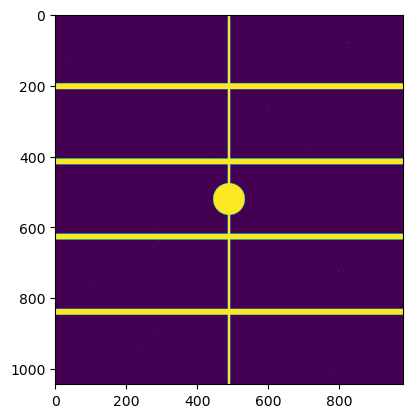

In [8]:
im_mask = np.zeros_like(im)
im_mask[im < 1] = 1
center_circle_mask = create_circular_mask(im.shape[0], im.shape[1], 45)
im_mask = np.logical_or(im_mask, center_circle_mask)

plt.imshow(im_mask)
plt.show()

# Data Import (Mandatory)

In [9]:
example_im_dir = '../data/from_martin/Martin_Variable_Sapphire_Spots/'
example_im_dir = '../data/from_martin/October_2025/'
example_im_files = glob(example_im_dir + '*.tiff')
example_im_files.sort()
example_im_files

['../data/from_martin/October_2025/4TUBS_M_25keV_250mm_30s_wobble_1_rt_1100_air 002.tiff',
 '../data/from_martin/October_2025/Gili_IrZO_25keV_250mm_30s_wobble_1_RT_400_air 026.tiff',
 '../data/from_martin/October_2025/KM_25keV_250mm_30s_wobble_1_rt_900_air 001.tiff',
 '../data/from_martin/October_2025/KM_25keV_250mm_30s_wobble_1_rt_900_air 031.tiff',
 '../data/from_martin/October_2025/KM_25keV_250mm_30s_wobble_1_rt_900_air 071.tiff',
 '../data/from_martin/October_2025/K_25keV_250mm_30s_wobble_1_rt_900_air 058.tiff',
 '../data/from_martin/October_2025/LaB6_25keV_250mm_60s_wobble_0_rt_air 007.tiff',
 '../data/from_martin/October_2025/YSZ5_25keV_250mm_30s_wobble_1_rt_1100_air 068.tiff',
 '../data/from_martin/October_2025/sw2_25keV_250mm_30s_wobble_1_rt_700_air 036.tiff',
 '../data/from_martin/October_2025/sw2_25keV_250mm_30s_wobble_1_rt_700_air 061.tiff']

In [10]:
#Directory info
#----------------
example_im_dir = '../data/from_martin/October_2025/'
# example_im_dir = '../data/from_martin/Texture_Examples/Shanece/'
example_im_files = glob(example_im_dir + '*.tiff')
example_im_files.sort()
# GEt image file first
idx = 3
im = iio.v2.volread(example_im_files[idx])
print(im.shape)
#Note to future self. Do NOT normalize the images before using median finder or else it simply won't work.
normalized_im = powder_normalize(im)

#Get poni file

# poni_path = '../data/from_martin/Martin_Variable_Sapphire_Spots/Calibration/LaB6_25keV_212mm_Pilatus_120623_1400.poni'
poni_path = '../data/from_martin/October_2025/LaB6_25keV_250mm_60s_wobble_0_rt_air 007_refined.poni'
# poni_path = '../data/from_martin/Texture_Examples/Shanece/LaB6Shanece.poni'


#IMCTRL version of Poni_path for masking
controls = convert_to_imctrl(poni_path)

#Direct computation of 2theta map
poni_params = parse_poni_file(poni_path)
theta_map, azm_map = create_2theta_map_poni(poni_params,im.shape)

#Creating mask
#Resetting the theta range to max instead of default ([0.8 17] approx)
controls['IOtth'] = [0.8, 26]
mask = MASK(controls, shape= im.shape)

im_to_mask = im
esdmul_mask = 1.5

result = mask.AutoSpotMask(im_to_mask, esdmul_mask, numchans=300)
extreme_result = mask.AutoSpotMask(im_to_mask, 10.0, numchans=300)

#Mask thresholding
#-------------------
sigma = 2.5  # Adjust this value for different smoothing levels
threshold = 0.75
# Apply island masking first
# island_mask = filter_connected_components_by_size(result, min_size = 2)
smoothed_mask = ndimage.gaussian_filter(result, sigma=sigma)

thresholded_mask = (smoothed_mask > threshold).astype(float)

#Additional thresholding for all super tiny values
thresholded_mask[im<5] = 1

# thresholded_mask = np.logical_or(thresholded_mask,extreme_result)




(1043, 981)
Tam length: 1023183
TA length: 1023183
Band length: 1023183
TThs length: 300
Starting up C code
esdmul: 1.5
Tam length: 1023183
TA length: 1023183
Band length: 1023183
TThs length: 300
Starting up C code
esdmul: 10.0


## Integration

In [11]:
# pyfai_poni_dir = '../data/from_martin/Martin_Variable_Sapphire_Spots/Calibration'
pyfai_poni_dir = '../data/from_martin/October_2025/'
pyfai_poni_path = glob(pyfai_poni_dir + '/*.poni')[0]
calibration_model = SimplifiedCalibrationModel()
calibration_model.load_poni(pyfai_poni_path)

dict = calibration_model.pattern_geometry.get_config()
dict['detector_config']['orientation'] = Orientation.TopRight

calibration_model.pattern_geometry.set_config(dict)
dict

Orientation is: 3
Flipped 1
Poni_dict after 2
OrderedDict([('poni_version', 2.1), ('detector', 'Detector'), ('detector_config', {'pixel1': 0.00017199999999999998, 'pixel2': 0.00017199999999999998, 'max_shape': None, 'orientation': <Orientation.TopRight: 2>}), ('dist', 0.23903039571336263), ('poni1', 0.08703320348756721), ('poni2', 0.08744424947529636), ('rot1', 0.009811068237567572), ('rot2', 0.0057253501985262915), ('rot3', 1.0495753778361941e-07), ('wavelength', 4.945060169084264e-11)])


OrderedDict([('poni_version', 2.1),
             ('detector', 'Detector'),
             ('detector_config',
              {'pixel1': 0.00017199999999999998,
               'pixel2': 0.00017199999999999998,
               'max_shape': None,
               'orientation': <Orientation.TopRight: 2>}),
             ('dist', 0.23903039571336263),
             ('poni1', 0.08703320348756721),
             ('poni2', 0.08744424947529636),
             ('rot1', 0.009811068237567572),
             ('rot2', 0.0057253501985262915),
             ('rot3', 1.0495753778361941e-07),
             ('wavelength', 4.945060169084264e-11)])

In [12]:
#Integration 

#Regular integration mask
regular_integration_mask = np.zeros_like(im)
regular_integration_mask[im < 20] = 1
center_circle_mask = create_circular_mask(im.shape[0], im.shape[1], 30)
regular_integration_mask = np.logical_or(regular_integration_mask, center_circle_mask)

#Integration mask with tailored mask
thresholded_mask[im<20] = 1
integration_mask = np.logical_or(thresholded_mask, center_circle_mask)

#Theta range
theta_range = [0.7, 26]

#Note the masks are masking OUT what you want to keep out (i.e. 1 means do not pick)
normal_integration = calibration_model.integrate_1d(im, 2500, mask = regular_integration_mask, unit = "2th_deg", theta_range = theta_range)
masked_integration = calibration_model.integrate_1d(im, 2500, mask = integration_mask, unit = "2th_deg", theta_range = theta_range)

In [73]:
np.sum(regular_integration_mask), np.sum(integration_mask)

(75954, 75973)

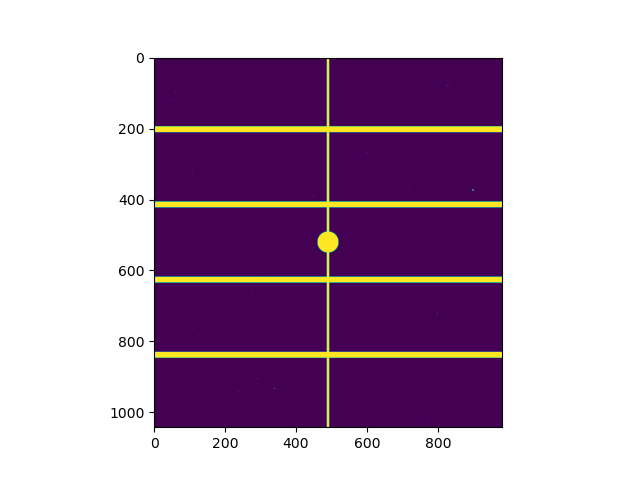

In [72]:
fig = plt.figure()
plt.imshow(integration_mask)

In [13]:
normal_integration[0][:5]

array([0.70506   , 0.71518   , 0.7253    , 0.73542   , 0.74554001])

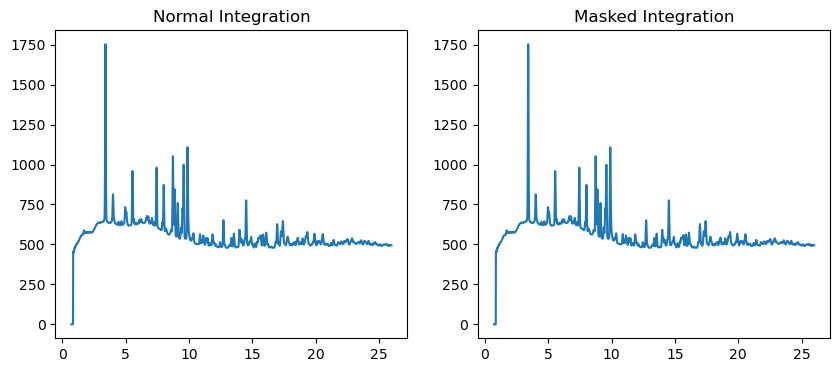

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))
ax[0].plot(*normal_integration)
ax[0].set_title('Normal Integration')
# ax[0].set_ylim([250, 370])

ax[1].plot(*masked_integration)
ax[1].set_title('Masked Integration')
plt.show()

# Azimuthal binning approach

In [15]:
%matplotlib widget
import c_algorithms.azimuthal_processing
importlib.reload(c_algorithms.azimuthal_processing)
from c_algorithms.azimuthal_processing import azimuthal_binning, count_spikes, extract_peak_patterns
import time
from mpl_toolkits.axes_grid1 import make_axes_locatable
import mplcursors

## Find peaks and their fwhm first

In [16]:
import airxd_cnn.spectral_processing
importlib.reload(airxd_cnn.spectral_processing)

<module 'airxd_cnn.spectral_processing' from '/home/av_linux/AIRXD-CNN/airxd_cnn/spectral_processing.py'>

In [17]:
from airxd_cnn.spectral_processing import calculate_acf_entropy, fast_spectral_entropy,_calculate_spectral_entropy_single
from scipy import signal
from sklearn.decomposition import PCA
from scipy.signal import find_peaks, peak_widths

In [18]:
def find_peaks_and_fwhm(
    integrated_pattern: np.ndarray, 
    two_theta_axis: np.ndarray,
    prominence: float = 1.0,
    distance: int = 4
) -> list[list[float]]:
    """
    Finds peaks in a 1D diffraction pattern and calculates their FWHM bounds.

    This function uses scipy.signal to robustly find peaks and then
    calculates the two-theta values corresponding to the full width at half
    maximum for each detected peak.

    Args:
        integrated_pattern (np.ndarray): 1D array of intensity values.
        two_theta_axis (np.ndarray): 1D array of corresponding two-theta values.
                                     Must be the same length as integrated_pattern.
        prominence (float, optional): The required prominence of peaks. This is a
                                      measure of how much a peak stands out from its
                                      surrounding baseline, which is often more robust
                                      than a simple height threshold. Defaults to 1.0.
        distance (int, optional): The minimum required horizontal distance (in number of
                                  data points) between neighboring peaks. Defaults to 50.

    Returns:
        list[list[float]]: A list where each inner list contains two floats:
                           [fwhm_min_two_theta, fwhm_max_two_theta]
                           for each detected peak, ready for use in the C++ algorithm.
    """
    if integrated_pattern.shape != two_theta_axis.shape:
        raise ValueError("Input pattern and two_theta_axis must have the same shape.")

    # --- Step 1: Find Peak Locations ---
    # find_peaks returns the indices of the peaks in the integrated_pattern array.
    # We use prominence and distance to filter out noise and closely spaced peaks.
    global_max = np.max(integrated_pattern)

    peaks, properties = find_peaks(
        integrated_pattern, 
        height = 0.005 * global_max,
        distance = 4,
        prominence = 0.01 * global_max)
    
    if peaks.size == 0:
        print("Warning: No peaks found with the given parameters.")
        return []

    # --- Step 2: Calculate Peak Widths (FWHM) ---
    # peak_widths calculates the width at a specified fraction of the peak's prominence.
    # For FWHM, this fraction is 0.5 (50%).
    # It returns the widths, the height of the width contour, and the interpolated
    # left and right indices of the width boundary.
    results = peak_widths(
        integrated_pattern, 
        peaks, 
        rel_height=0.5  # This specifies FWHM
    )
    
    # Unpack the results from peak_widths
    widths, width_heights, left_ips, right_ips = results

    # --- Step 3: Convert Width Boundary Indices to Two-Theta Values ---
    # The 'left_ips' and 'right_ips' are the interpolated indices. We need to map
    # these indices to their corresponding values on the two_theta_axis.
    # np.interp is perfect for this task.
    
    # The x-coordinates of our data points are simply their indices.
    data_point_indices = np.arange(len(two_theta_axis))
    
    fwhm_left_thetas = np.interp(left_ips, data_point_indices, two_theta_axis)
    fwhm_right_thetas = np.interp(right_ips, data_point_indices, two_theta_axis)

    # --- Step 4: Format for C++ Algorithm ---
    # Combine the left and right theta values into the required format.
    peak_bounds = [[left, right] for left, right in zip(fwhm_left_thetas, fwhm_right_thetas)]

    for i, (left_bound, right_bound) in enumerate(peak_bounds):
        # Set minimum fwhm threshold
        if (right_bound-left_bound) <= 0.07:
            center = (right_bound+left_bound)/2
            peak_bounds[i] = [center-0.035, center+0.035]
    
    # For visualization and debugging, we can return all the data
    debug_info = {
        'peaks': peaks,
        'peak_thetas': two_theta_axis[peaks],
        'prominences': properties['prominences'],
        'fwhm_bounds_indices': (left_ips, right_ips),
        'fwhm_width_thetas': fwhm_right_thetas - fwhm_left_thetas,
        'width_heights': width_heights
    }

    return integrated_pattern[peaks], peaks, peak_bounds, debug_info

In [19]:
peaks, peak_idxs, peak_bounds, debug_info = find_peaks_and_fwhm(masked_integration[1], masked_integration[0])

(array([32.,  6.,  3.,  3.,  2.,  0.,  3.,  1.,  0.,  1.,  0.,  1.,  2.,
         1.,  0.,  1.,  1.,  0.,  0.,  1.]),
 array([0.07      , 0.08100233, 0.09200467, 0.103007  , 0.11400934,
        0.12501167, 0.13601401, 0.14701634, 0.15801867, 0.16902101,
        0.18002334, 0.19102568, 0.20202801, 0.21303034, 0.22403268,
        0.23503501, 0.24603735, 0.25703968, 0.26804202, 0.27904435,
        0.29004668]),
 <BarContainer object of 20 artists>)

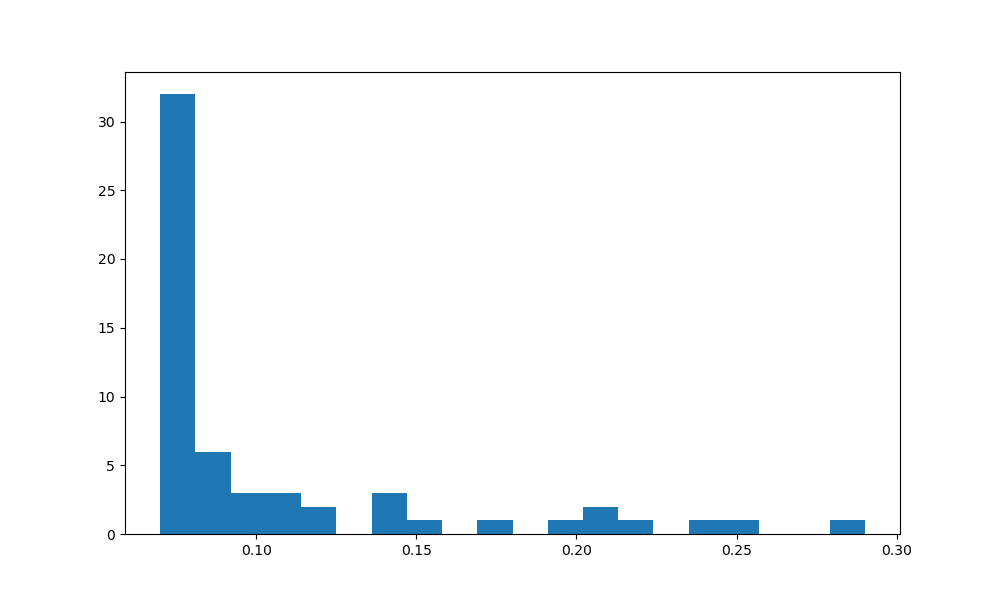

In [20]:
test = np.array(peak_bounds)
diff = test[:,1] - test[:,0]
np.min(diff), np.max(diff)

plt.figure(figsize=(10,6))
plt.hist(diff,bins = 20)

#### Plotting to check

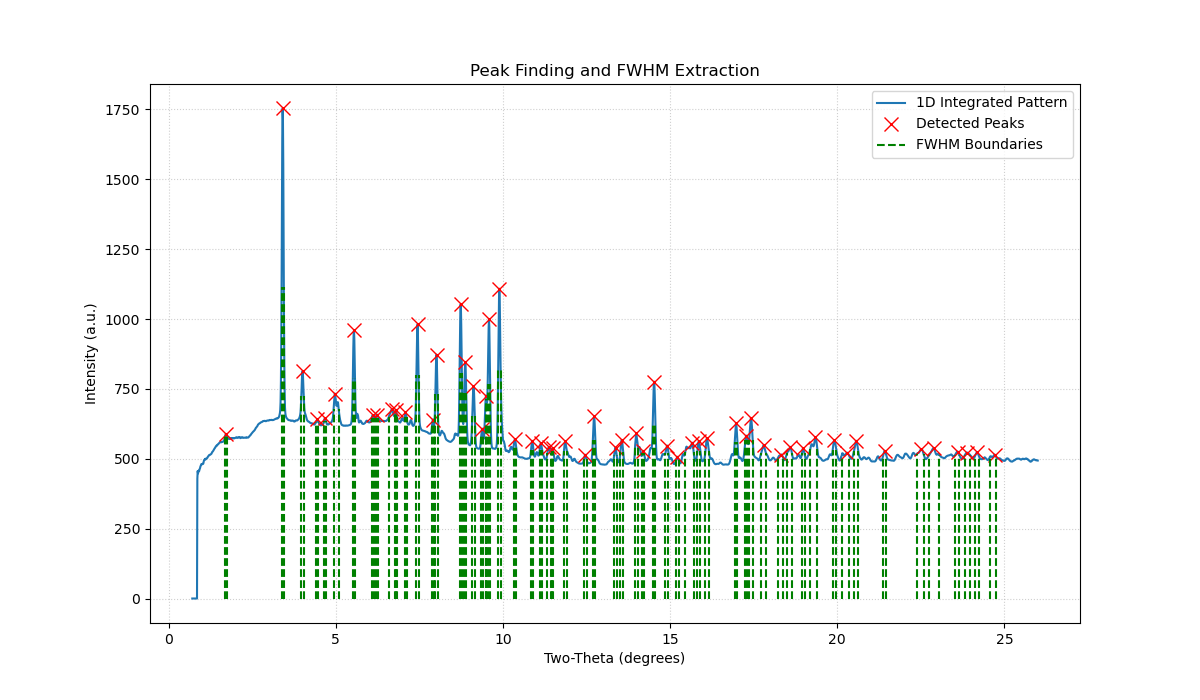

In [21]:
two_theta_axis = masked_integration[0]
integrated_pattern = masked_integration[1]

plt.figure(figsize=(12,7))
plt.plot(two_theta_axis, integrated_pattern, label='1D Integrated Pattern')

# Plot the detected peak locations
plt.plot(
    debug_info['peak_thetas'], 
    integrated_pattern[debug_info['peaks']], 
    "x", 
    color='red', 
    markersize=10, 
    label='Detected Peaks'
)

# Plot the FWHM horizontal lines

# First, calculate the two-theta values for the FWHM boundaries correctly.
fwhm_left_ips, fwhm_right_ips = debug_info['fwhm_bounds_indices']
data_point_indices = np.arange(len(two_theta_axis))

# Interpolate the left and right boundaries separately to get their two-theta values
fwhm_left_thetas = np.interp(fwhm_left_ips, data_point_indices, two_theta_axis)
fwhm_right_thetas = np.interp(fwhm_right_ips, data_point_indices, two_theta_axis)

# Get the y-coordinates for the tops of the FWHM lines
fwhm_heights = debug_info['width_heights']

# Get a common baseline y-coordinate for the bottoms of the lines
plot_baseline = np.min(integrated_pattern) 

# Plot the left and right boundary lines. We do this in one call for the legend.
plt.vlines(
    x=fwhm_left_thetas, 
    ymin=plot_baseline, 
    ymax=fwhm_heights, 
    color="green", 
    linestyle='--',
    label='FWHM Boundaries' # Assign the label here
)
plt.vlines(
    x=fwhm_right_thetas, 
    ymin=plot_baseline, 
    ymax=fwhm_heights, 
    color="green", 
    linestyle='--'
    # No label here to avoid duplicates in the legend
)

plt.title("Peak Finding and FWHM Extraction")
plt.xlabel("Two-Theta (degrees)")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## Azimuthal FWHM binning

In [22]:
def create_azimuthal_fwhm_bins(img, TA, TT, mask, peak_bounds, num_azimuthal_bins=3000):
    """
    img : numpy.ndarray (N x M)
          powder diffraction image (raw, unnormalized)
    TA :  numpy.ndarray (N x M)
          theta-azimuthal map (N X M)
    mask : numpy.ndarray (N x M)
          masking map (N X M)

    """

    img = np.asarray(img, dtype = np.float64)
    TA = np.asarray(TA, dtype = np.float64)
    TT = np.asarray(TT, dtype = np.float64)
    mask = np.asarray(mask, dtype = np.int32)

    if not np.all(np.isin(mask, [0, 1])):
        raise ValueError("All values in mask must be binary")
    
    start_time = time.perf_counter()
    rings = extract_peak_patterns(
        img, TA, TT, mask, peak_bounds, num_azimuthal_bins)
    print(f'Execution time: {time.perf_counter() - start_time}')

    return rings
    
def degrees_to_radians_wrapped(degrees_image):
    """
    Convert degrees (0-360) to radians (-π to π)
    """
    # Convert degrees to radians
    radians = np.deg2rad(degrees_image)
    
    # Wrap to [-π, π] range
    radians_wrapped = np.arctan2(np.sin(radians), np.cos(radians))
    
    return radians_wrapped

In [23]:
peak_azimuthal_rings = create_azimuthal_fwhm_bins(im, degrees_to_radians_wrapped(azm_map), theta_map, integration_mask,
                                                  peak_bounds, 3000)

Execution time: 0.069930633995682


Going to plot the diffraction patterns so I can see which thetas are usable

In [24]:
len(peak_azimuthal_rings)

58

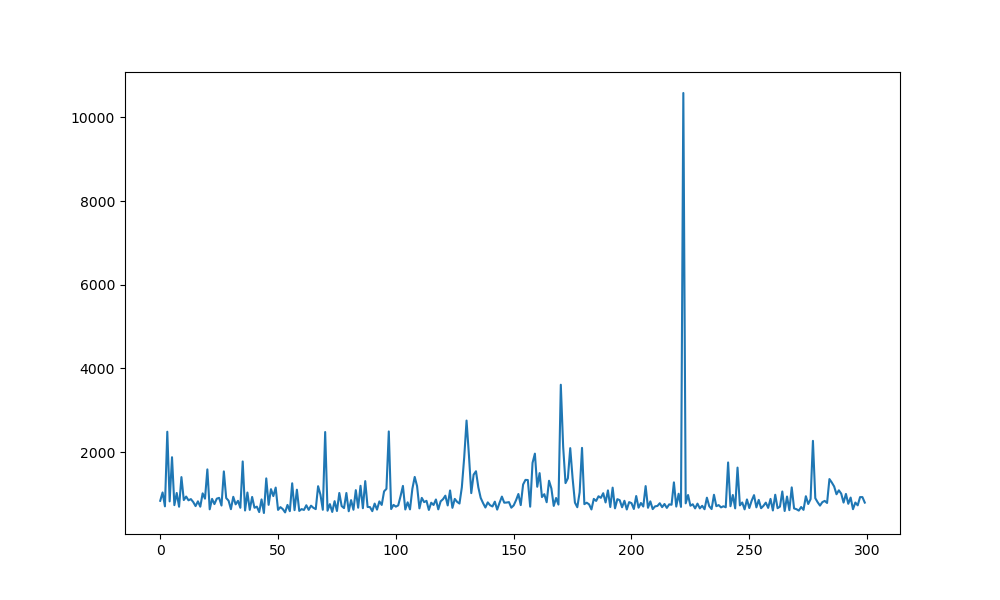

In [99]:
series = peak_azimuthal_rings[1]
series = series[series!=0]
fig = plt.figure(figsize = (10,6))
plt.plot(np.arange(len(series)), series)
plt.show()

# Spectral processing/binning

In [25]:
import airxd_cnn.spectral_processing
importlib.reload(airxd_cnn.spectral_processing)
from airxd_cnn.spectral_processing import fast_spectral_entropy, _calculate_spectral_entropy_single, fast_spectra_binning, calculate_acf_entropy
from scipy import signal
from sklearn.decomposition import PCA
from scipy.signal import find_peaks

## Peak finder so we can highlight the points of actual interest on the scatter

In [26]:
#Get corrected intensity vector accounting for coarse-grained theta
#You'll get some subset of the integrated 1D pattern with theta vals corresponding to the coarse-grained 2theta values in "theta"
acf = []
spectral_entropy = []

for i, ring in enumerate(peak_azimuthal_rings):
    ring = ring[ring!=0]
    if len(ring) < 100:
        coarse_acf_i = 0
        single_entropy_i = 0
    else:
        coarse_acf_i = calculate_acf_entropy(ring, max_lag=60)
        single_entropy_i = _calculate_spectral_entropy_single(ring)[0]

    acf.append(coarse_acf_i)
    spectral_entropy.append(single_entropy_i)

# Turn all arrays into 2D for SVD
spectral_entropy = np.array(spectral_entropy).transpose()[:,None]
peak_vals = np.array(masked_integration[0][peak_idxs]).transpose()[:,None]
acf = np.array(acf).transpose()[:,None]
acf /= np.max(acf)



## Visualizing the peaks

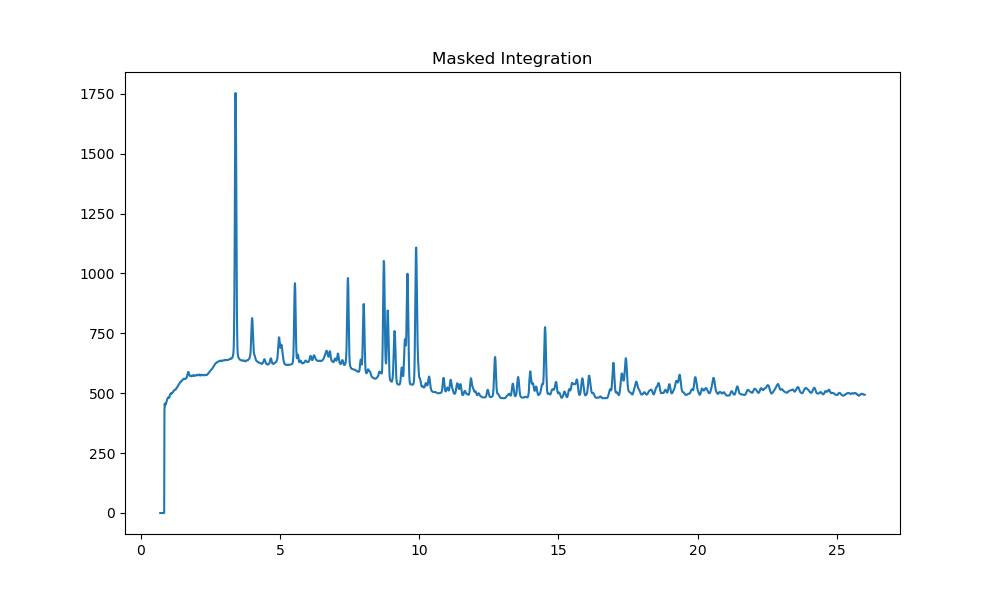

In [27]:
fig = plt.figure(figsize=(10,6))
plt.plot(*masked_integration)
plt.title('Masked Integration')
plt.show()

# Plotting PCA results

### Custom adding a few prominent indices that were missed

**This is for HK-6_25keV_213mm_30secs_rt-1000_05Ar 0091.Tiff specifically**
550, 649, 439

In [103]:
import matplotlib.pyplot as plt
import numpy as np
import mplcursors
from sklearn.decomposition import PCA

### Continuing

In [104]:
# feature_vector = np.vstack(spectral_bin_vals)
# Add intensity
feature_vector = np.hstack((spectral_entropy, acf))
pca = PCA(n_components=2)
transformed_data = pca.fit_transform(feature_vector)

### Plotting function

In [105]:
def plot_interactive_peaks(peak_list, peak_idx, feature_list, theta_array):
    """
    Create an interactive scatter plot of peak features with tooltips showing theta and intensity.
    
    Parameters:
    - peak_list: List of peak intensities (same length as peak_idx and feature_list)
    - peak_idx: List of indices into theta_array (same length as peak_list and feature_list)
    - feature_list: List of 2D features for each peak (shape: N x 2)
    - theta_array: Full 2-theta array that peak_idx indexes into
    """
    
    # Convert to numpy arrays for easier handling
    peak_list = np.array(peak_list)
    peak_idx = np.array(peak_idx)
    feature_list = np.array(feature_list)
    theta_array = np.array(theta_array)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(7,7))
    
    # Create scatter plot using the 2D features
    scatter = ax.scatter(
        feature_list[:, 0], 
        feature_list[:, 1], 
        alpha=0.7,
        s=50,  # marker size
        c='blue',
        label='XRD Peaks'
    )
    
    # Set labels and title
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title('Interactive XRD Peak Feature Plot')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Create interactive cursor
    cursor = mplcursors.cursor(scatter, hover=True)
    
    @cursor.connect("add")
    def on_add(sel):
        # Get the clicked point coordinates
        x, y = sel.target
        
        # Find the closest point in feature space
        distances = np.sum((feature_list - np.array([x, y]))**2, axis=1)
        point_idx = np.argmin(distances)
        
        # Get the corresponding theta value and intensity
        theta_value = theta_array[peak_idx[point_idx]]
        intensity_value = peak_list[point_idx]
        
        # Set the tooltip text
        sel.annotation.set_text(
            f'Peak {point_idx}\n'
            f'2θ: {theta_value:.3f}°\n'
            f'Intensity: {intensity_value:.1f}\n'
        )
        
        # Optional: print to console for debugging
        print(f"Selected peak {point_idx}: 2θ={theta_value:.3f}°, I={intensity_value:.1f}")
    
    plt.tight_layout()
    plt.show()

### Plotted PCA

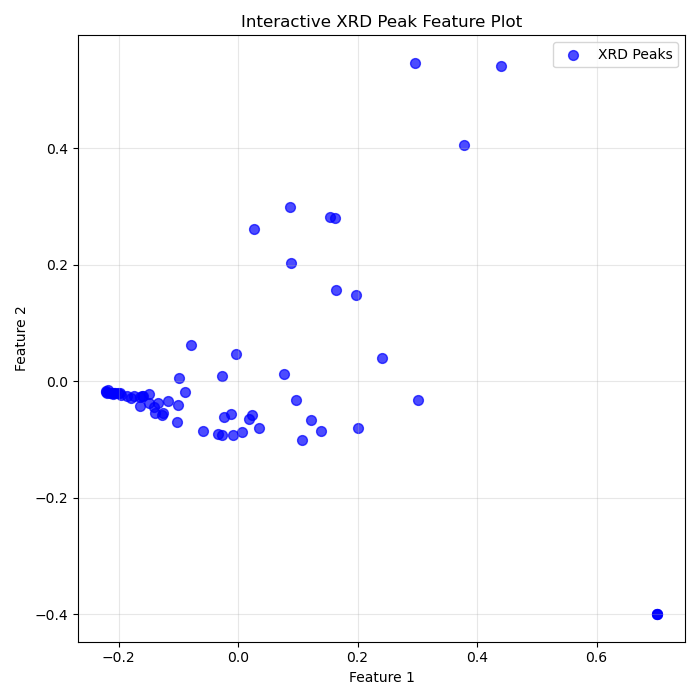

In [106]:
plot_interactive_peaks(peaks,peak_idxs,transformed_data,masked_integration[0])

### Single angle plotting

In [107]:
masked_integration[0][peak_idxs][:20], masked_integration[1][peak_idxs][20]

(array([0.85686002, 1.5045401 , 3.01242028, 3.42734033, 3.73094037,
        4.0041804 , 4.20658043, 4.51018047, 4.7733005 , 4.94534052,
        5.31978057, 5.66386061, 6.29130068, 6.91874076, 7.04018078,
        7.2628208 , 7.45510083, 8.0319409 , 8.22422092, 8.34566094]),
 970.34015)

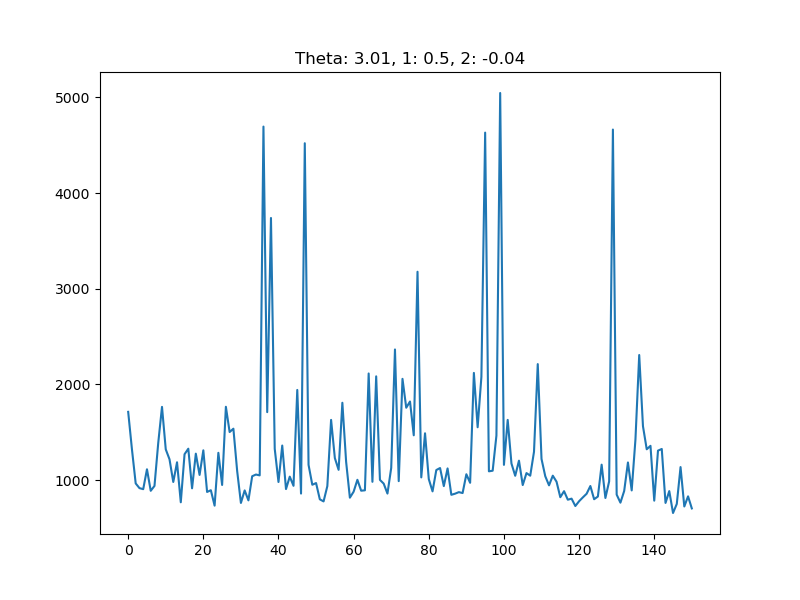

In [83]:
theta_to_plot = 3.007
peak_thetas = masked_integration[0][peak_idxs]

idx = np.argmin(np.abs(theta_to_plot - peak_thetas))

ring_to_plot = peak_azimuthal_rings[idx]
ring_to_plot = ring_to_plot[ring_to_plot != 0]
new_fig = plt.figure(figsize=(8, 6))
plt.plot(np.arange(len(ring_to_plot)), ring_to_plot)
plt.title(f'Theta: {round(masked_integration[0][peak_idxs[idx]],2)}, 1: {round(transformed_data[idx,0],2)}, 2: {round(transformed_data[idx,1],2)}')
plt.show()




# Looking at inter-peak distances to see if there are trends

First trying out scipy.signal.find_peaks

In [57]:
from scipy.signal import find_peaks


In [ ]:
#Same code from above
theta_to_plot = 7.17
peak_thetas = masked_integration[0][peak_idxs]

idx = np.argmin(np.abs(theta_to_plot - peak_thetas))

ring_to_plot = peak_azimuthal_rings[idx]
ring_to_plot = ring_to_plot[ring_to_plot != 0]

peaks_idx, props = find_peaks(ring_to_plot,
                      prominence=430,
                      distance=3,
                      height=np.median(ring_to_plot))

inter_peak_distances = np.diff(peaks_idx)

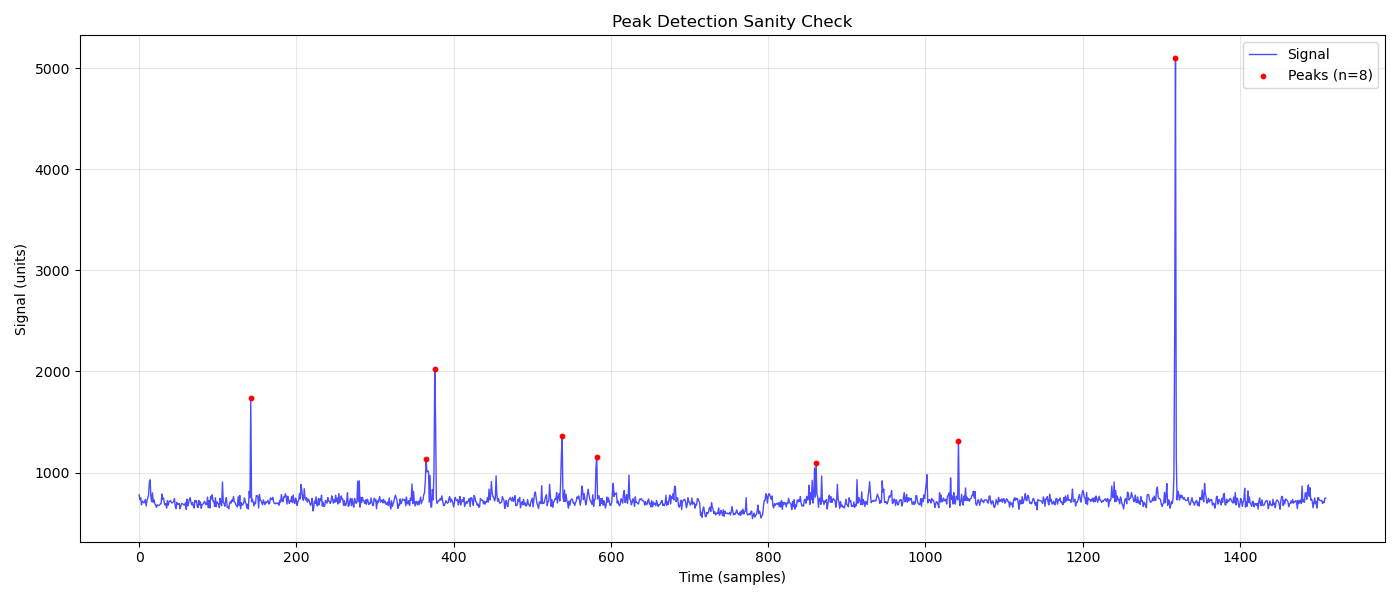

In [ ]:
# Create the plot
y = ring_to_plot
plt.figure(figsize=(14, 6))

# Plot the time series
plt.plot(y, 'b-', linewidth=1, label='Signal', alpha=0.7)

# Highlight peaks with scatter plot
plt.scatter(peaks_idx, y[peaks_idx], 
           color='red', 
           s=10,  # marker size
           marker='o', 
           label=f'Peaks (n={len(peaks_idx)})',
           zorder=5)  # ensure peaks are drawn on top

# Optional: add vertical lines at peak positions for extra visibility
# for peak in peaks:
#     plt.axvline(x=peak, color='red', alpha=0.2, linewidth=0.5, linestyle='--')

plt.xlabel('Time (samples)')
plt.ylabel('Signal (units)')
plt.title('Peak Detection Sanity Check')

# plt.xlim([0,600])
# plt.ylim([700,1500])


plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

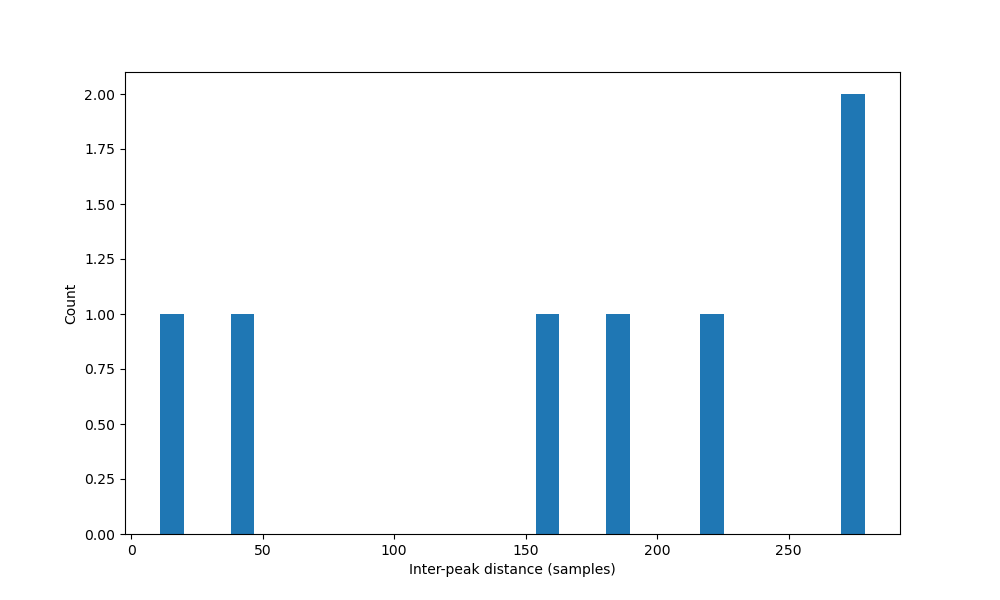

In [114]:
# Plotting inter-peak distance distribution
plt.figure(figsize=(10,6))
plt.hist(inter_peak_distances, bins = 30)
plt.xlabel("Inter-peak distance (samples)")
plt.ylabel('Count')
plt.show()


This approach does not work well because the inter-peak distances don't show much about the "bunching", since most of the datapoints are within the bunches anyways. We can look at some sort of density estimate instead

### Density estimate approach

In [115]:
def local_peak_density(peaks, window_size=100, step=10):
    """
    Calculate how peak density varies across the signal
    High CV indicates bunching
    """
    signal_length = peaks[-1]
    densities = []
    positions = []
    
    for start in range(0, signal_length - window_size, step):
        end = start + window_size
        # Count peaks in this window
        n_peaks = np.sum((peaks >= start) & (peaks < end))
        densities.append(n_peaks)
        positions.append(start + window_size/2)
    
    densities = np.array(densities)
    
    # Coefficient of variation: std/mean
    # High CV = high bunching, Low CV = uniform
    cv = np.std(densities) / np.mean(densities)
    
    return positions, densities, cv

def local_integrated_peak_density(peaks, heights, window_size = 100, step = 10):

    signal_length = peaks[-1]
    densities = []
    positions = []
    
    for start in range(0, signal_length - window_size, step):
        end = start + window_size
        # Count peaks in this window
        peak_idxs = (peaks >= start) & (peaks < end)
        densities.append(np.sum(heights[peak_idxs]))
        positions.append(start + window_size/2)
    
    densities = np.array(densities)

    return positions, densities

#### Local Density

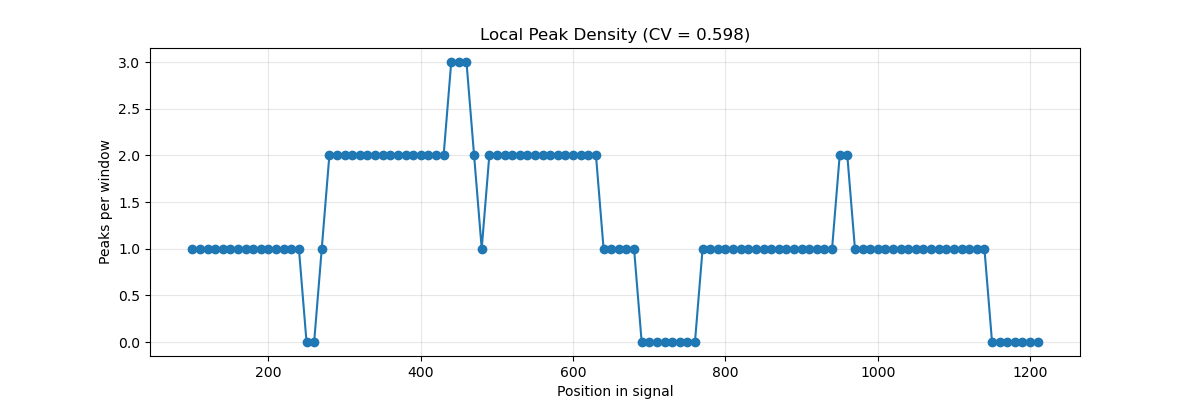

Coefficient of Variation: 0.598
CV > 0.5 suggests bunching, CV < 0.3 suggests uniformity


In [116]:
#Plotting simply peak density
positions, densities, cv = local_peak_density(peaks, window_size=200)

plt.figure(figsize=(12, 4))
plt.plot(positions, densities, 'o-')
plt.xlabel('Position in signal')
plt.ylabel('Peaks per window')
plt.title(f'Local Peak Density (CV = {cv:.3f})')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Coefficient of Variation: {cv:.3f}")
print(f"CV > 0.5 suggests bunching, CV < 0.3 suggests uniformity")

#### Local Integrated Density

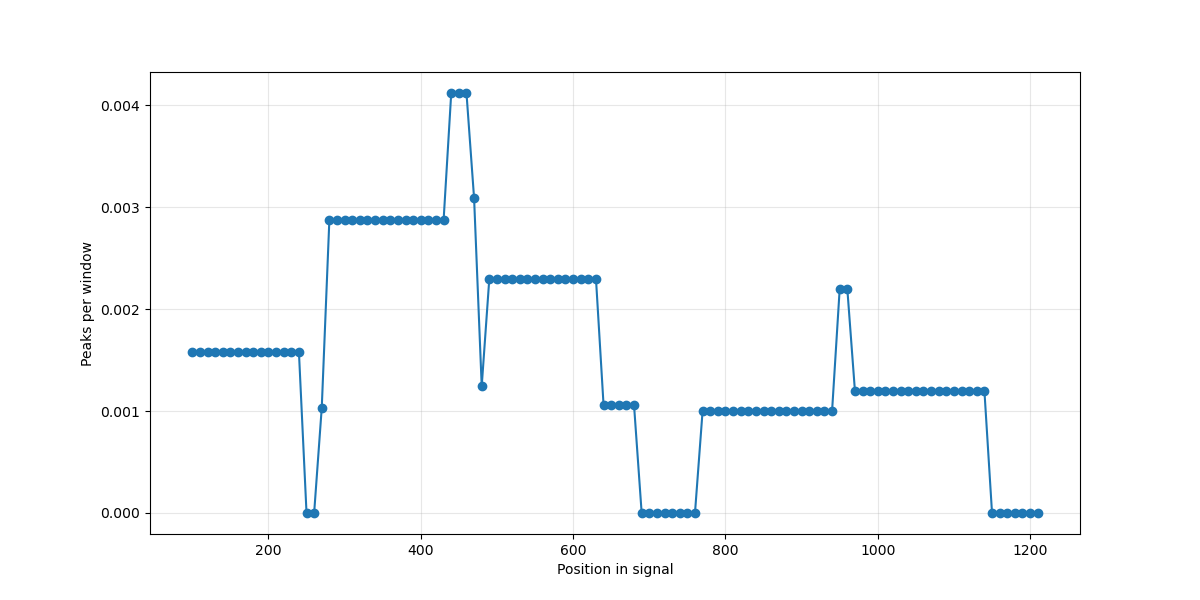

In [117]:
#Plotting local integrated peak density
positions, densities = local_integrated_peak_density(peaks, props['peak_heights'],
                                                     window_size = 200)

densities /= np.sum(ring_to_plot)
plt.figure(figsize=(12,6))
plt.plot(positions,densities, 'o-')
plt.xlabel('Position in signal')
plt.ylabel('Peaks per window')
plt.grid(True, alpha=0.3)
plt.show()

Looks to work well, we now just need to decide how to dynamically threshold the prominence so we get an accurate peak distribution

### Dynamic thresholding using a CDF-based approach

In [118]:
def adaptive_prominence_from_cdf(signal, initial_prominence=200, 
                                             percentile_threshold=25,
                                             visualize=False,
                                             densities = None):
    """
    Filter peaks based on their prominence values rather than heights
    Better for signals with varying baselines
    """
    
    # Find all peaks
    all_peaks, properties = find_peaks(signal, prominence=initial_prominence,
                                       distance=3,
                                       height=np.median(signal))
    
   
    if len(all_peaks) == 0:
        print("No peaks found!")
        return np.array([]), None, np.array([]), None
    
    # Get prominences (how much peak stands out from baseline)
    peak_prominences = properties['prominences']
    
    # Calculate threshold
    threshold_prominence = np.percentile(peak_prominences, percentile_threshold)
    
    # Filter peaks
    final_peaks = all_peaks[peak_prominences >= threshold_prominence]

    #Peak density distribution
    positions, densities = local_integrated_peak_density(final_peaks, properties['peak_heights'][peak_prominences >= threshold_prominence],
                                                            window_size=70)
    
    if visualize:
        fig, axes = plt.subplots(3, 1, figsize=(12, 10))
        
        # CDF of prominences
        sorted_prom = np.sort(peak_prominences)
        cdf = np.arange(1, len(sorted_prom) + 1) / len(sorted_prom) * 100
        
        axes[0].plot(sorted_prom, cdf, 'b-', linewidth=2)
        axes[0].axvline(threshold_prominence, color='red', linestyle='--', 
                       linewidth=2, label=f'{percentile_threshold}th percentile')
        axes[0].set_xlabel('Peak Prominence')
        axes[0].set_ylabel('Cumulative Percentage')
        axes[0].set_title(f'CDF of Peak Prominences\nThreshold: {threshold_prominence:.1f}')
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()
        
        # Signal with peaks
        axes[1].plot(signal, 'b-', linewidth=1, alpha=0.5)
        axes[1].scatter(all_peaks, signal[all_peaks], 
                       color='gray', s=10, alpha=0.3, 
                       label=f'All peaks (n={len(all_peaks)})')
        axes[1].scatter(final_peaks, signal[final_peaks], 
                       color='red', s=20, zorder=5,
                       label=f'Filtered peaks (n={len(final_peaks)})')
        axes[1].set_xlabel('Time (samples)')
        axes[1].set_ylabel('Signal')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        
        
        axes[2].plot(positions, densities, 'o-')
        axes[2].set_xlabel('Position in signal')
        axes[2].set_ylabel('Peak integrated counts per window')
        # axes[2].set_title(f'Local Peak Density (CV = {cv:.3f})')
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    print(f"Prominence threshold: {threshold_prominence:.2f}")
    print(f"Peaks retained: {len(final_peaks)}/{len(all_peaks)}")
    
    return final_peaks, threshold_prominence, all_peaks, densities

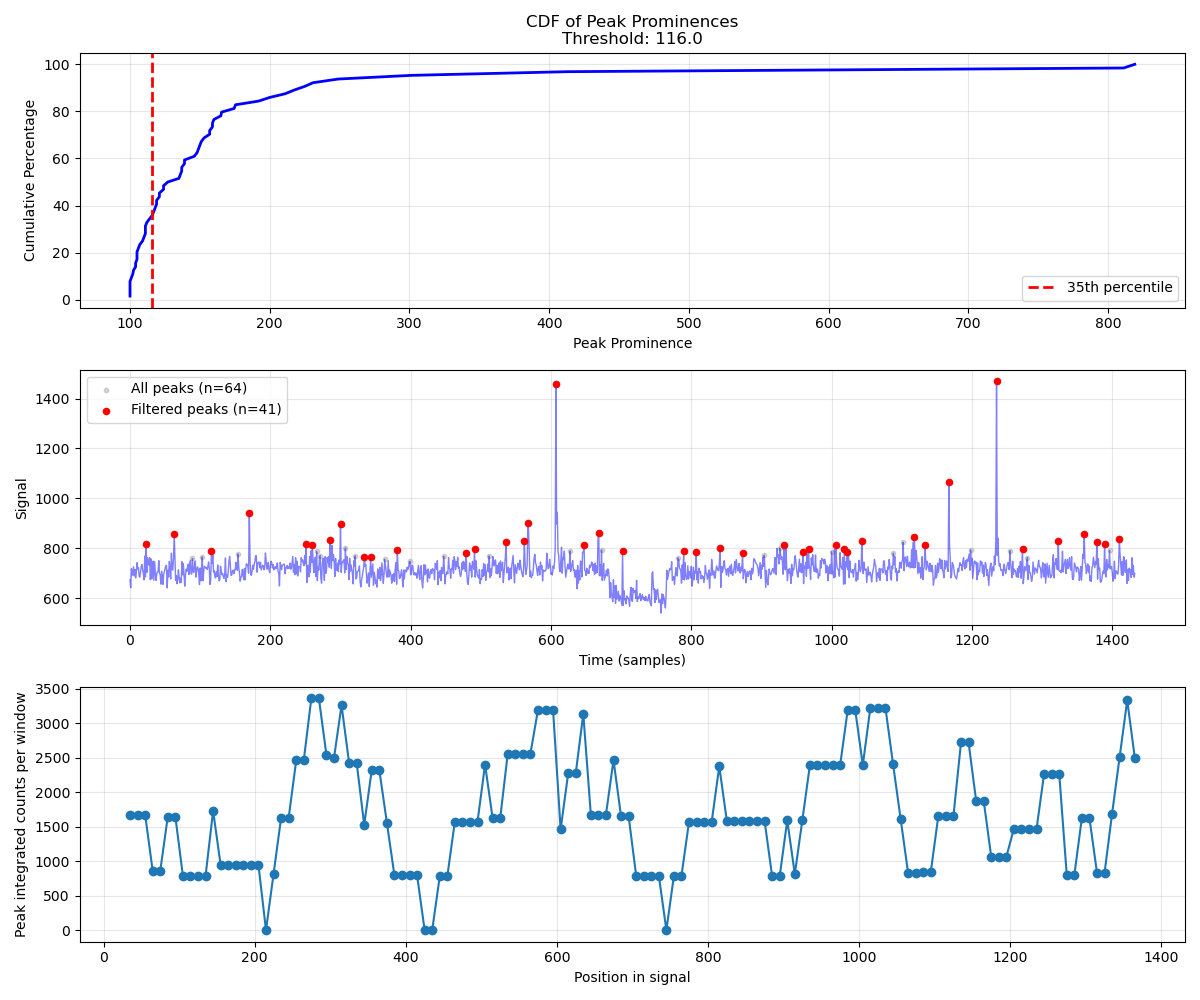

Prominence threshold: 116.05
Peaks retained: 41/64


In [119]:
#Same code from above
theta_to_plot = 6.12
peak_thetas = masked_integration[0][peak_idxs]
idx = np.argmin(np.abs(theta_to_plot - peak_thetas))
ring_to_plot = peak_azimuthal_rings[idx]
ring_to_plot = ring_to_plot[ring_to_plot != 0]

final_peaks, threshold, all_peaks, densities = adaptive_prominence_from_cdf(
    ring_to_plot, 
    initial_prominence=100,
    percentile_threshold=35,  # Keep peaks above 25th percentile (top 75%)
    visualize=True
)

Seems like we can use a combination of stat ratios (mean/std, etc.) of the density distribution to help classify distributions. This helps characterize the "bunching" of the peaks. The more bunching there is in the integrated plot, the larger the standard deviation relative to the mean. Otherwise the std << mean and we have more of a normal distribution

Text(0.5, 1.0, 'Mean/std: 2.075')

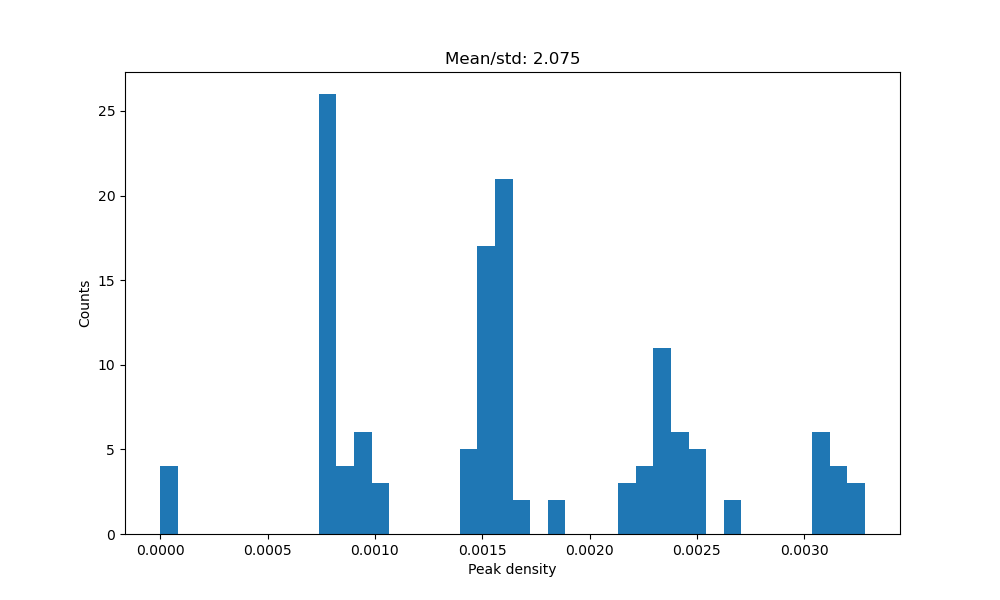

In [120]:
normalized_densities = densities / np.sum(ring_to_plot)

plt.figure(figsize=(10,6))
plt.hist(normalized_densities,bins = 40)
plt.xlabel("Peak density")
plt.ylabel("Counts")
mm_ratio = np.mean(densities)/np.std(densities)
plt.title(f"Mean/std: {mm_ratio:.4g}")



In [180]:
np.std(normalized_densities), np.mean(normalized_densities), np.median(normalized_densities)

(0.0015180947698408573, 0.0018591391179084565, 0.001447522043148223)

# Adding these peak density based features to what we already have

## Calculating density distribution statistics for all peaks


### Helper functions

In [34]:
def plot_interactive_peaks(peak_list, peak_idx, feature_list, theta_array):
    """
    Create an interactive scatter plot of peak features with tooltips showing theta and intensity.
    
    Parameters:
    - peak_list: List of peak intensities (same length as peak_idx and feature_list)
    - peak_idx: List of indices into theta_array (same length as peak_list and feature_list)
    - feature_list: List of 2D features for each peak (shape: N x 2)
    - theta_array: Full 2-theta array that peak_idx indexes into
    """
    
    # Convert to numpy arrays for easier handling
    peak_list = np.array(peak_list)
    peak_idx = np.array(peak_idx)
    feature_list = np.array(feature_list)
    theta_array = np.array(theta_array)
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(7,7))
    
    # Create scatter plot using the 2D features
    scatter = ax.scatter(
        feature_list[:, 0], 
        feature_list[:, 1], 
        alpha=0.7,
        s=50,  # marker size
        c='blue',
        label='XRD Peaks'
    )
    
    # Set labels and title
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title('Interactive XRD Peak Feature Plot')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Create interactive cursor
    cursor = mplcursors.cursor(scatter, hover=True)
    
    @cursor.connect("add")
    def on_add(sel):
        # Get the clicked point coordinates
        x, y = sel.target
        
        # Find the closest point in feature space
        distances = np.sum((feature_list - np.array([x, y]))**2, axis=1)
        point_idx = np.argmin(distances)
        
        # Get the corresponding theta value and intensity
        theta_value = theta_array[peak_idx[point_idx]]
        intensity_value = peak_list[point_idx]
        
        # Set the tooltip text
        sel.annotation.set_text(
            f'Peak {point_idx}\n'
            f'2θ: {theta_value:.3f}°\n'
            f'Intensity: {intensity_value:.1f}\n'
        )
        
        # Optional: print to console for debugging
        print(f"Selected peak {point_idx}: 2θ={theta_value:.3f}°, I={intensity_value:.1f}")
    
    plt.tight_layout()
    plt.show()

def local_peak_density(peaks, window_size=100, step=10):
    """
    Calculate how peak density varies across the signal
    High CV indicates bunching
    """
    signal_length = peaks[-1]
    densities = []
    positions = []
    
    for start in range(0, signal_length - window_size, step):
        end = start + window_size
        # Count peaks in this window
        n_peaks = np.sum((peaks >= start) & (peaks < end))
        densities.append(n_peaks)
        positions.append(start + window_size/2)
    
    densities = np.array(densities)
    
    # Coefficient of variation: std/mean
    # High CV = high bunching, Low CV = uniform
    cv = np.std(densities) / np.mean(densities)
    
    return positions, densities, cv

def local_integrated_peak_density(peaks, heights, window_size = 100, step = 10):

    signal_length = peaks[-1]
    densities = []
    positions = []
    
    for start in range(0, signal_length - window_size, step):
        end = start + window_size
        # Count peaks in this window
        peak_idxs = (peaks >= start) & (peaks < end)
        densities.append(np.sum(heights[peak_idxs]))
        positions.append(start + window_size/2)
    
    densities = np.array(densities)

    return positions, densities

def adaptive_prominence_from_cdf(signal, initial_prominence=200, 
                                             percentile_threshold=25,
                                             visualize=False,
                                             densities = None):
    """
    Filter peaks based on their prominence values rather than heights
    Better for signals with varying baselines
    """
    
    # Find all peaks
    all_peaks, properties = find_peaks(signal, prominence=initial_prominence,
                                       distance=3,
                                       height=np.median(signal))
    
   
    if len(all_peaks) == 0:
        print("No peaks found!")
        return np.array([]), None, np.array([]), None
    
    # Get prominences (how much peak stands out from baseline)
    peak_prominences = properties['prominences']
    
    # Calculate threshold
    threshold_prominence = np.percentile(peak_prominences, percentile_threshold)
    
    # Filter peaks
    final_peaks = all_peaks[peak_prominences >= threshold_prominence]

    #Peak density distribution
    positions, densities = local_integrated_peak_density(final_peaks, properties['peak_heights'][peak_prominences >= threshold_prominence],
                                                            window_size=70)
    
    if visualize:
        fig, axes = plt.subplots(3, 1, figsize=(12, 10))
        
        # CDF of prominences
        sorted_prom = np.sort(peak_prominences)
        cdf = np.arange(1, len(sorted_prom) + 1) / len(sorted_prom) * 100
        
        axes[0].plot(sorted_prom, cdf, 'b-', linewidth=2)
        axes[0].axvline(threshold_prominence, color='red', linestyle='--', 
                       linewidth=2, label=f'{percentile_threshold}th percentile')
        axes[0].set_xlabel('Peak Prominence')
        axes[0].set_ylabel('Cumulative Percentage')
        axes[0].set_title(f'CDF of Peak Prominences\nThreshold: {threshold_prominence:.1f}')
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()
        
        # Signal with peaks
        axes[1].plot(signal, 'b-', linewidth=1, alpha=0.5)
        axes[1].scatter(all_peaks, signal[all_peaks], 
                       color='gray', s=10, alpha=0.3, 
                       label=f'All peaks (n={len(all_peaks)})')
        axes[1].scatter(final_peaks, signal[final_peaks], 
                       color='red', s=20, zorder=5,
                       label=f'Filtered peaks (n={len(final_peaks)})')
        axes[1].set_xlabel('Time (samples)')
        axes[1].set_ylabel('Signal')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        
        
        axes[2].plot(positions, densities, 'o-')
        axes[2].set_xlabel('Position in signal')
        axes[2].set_ylabel('Peak integrated counts per window')
        # axes[2].set_title(f'Local Peak Density (CV = {cv:.3f})')
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    print(f"Prominence threshold: {threshold_prominence:.2f}")
    print(f"Peaks retained: {len(final_peaks)}/{len(all_peaks)}")
    
    return final_peaks, threshold_prominence, all_peaks, densities

### Continue

In [28]:
import scipy.stats as stats

In [30]:
means = []
medians = []
stds = []
skews = []
sums = []
num_peaks = []

for i in range(len(peak_azimuthal_rings)):
    ring_to_plot = peak_azimuthal_rings[i]
    ring_to_plot = ring_to_plot[ring_to_plot != 0]

    final_peaks, _, _, densities = adaptive_prominence_from_cdf(
        ring_to_plot, 
        initial_prominence=100,
        percentile_threshold=35,  # Keep peaks above 25th percentile (top 75%)
        visualize=False
    )

    total_ring_sum = np.sum(ring_to_plot)

    if densities is not None:
        densities /= total_ring_sum
    else:
        densities = 0

    means.append(np.mean(densities))
    medians.append(np.median(densities))
    stds.append(np.std(densities))
    skews.append(stats.skew(densities))
    
    #Calculating sum of peaks versus total
    if not final_peaks.any():
        final_peak_vals = [0]
    else:
        final_peak_vals = ring_to_plot[final_peaks]
        
    sums.append(np.sum(final_peak_vals)/(total_ring_sum+1e-6))

    #Num peaks
    if densities is not None:
        num_peaks.append(len(final_peaks))
    else:
        num_peaks.append(0)


means = np.array(means)
medians = np.array(medians)
stds = np.array(stds)
skews = np.array(skews)
num_peaks = np.array(num_peaks)

#Get rid of nans
skews[np.isnan(skews)] = 0
means[np.isnan(means)] = 0
stds[np.isnan(stds)] = 0

Prominence threshold: 115.35
Peaks retained: 5/8
Prominence threshold: 819.00
Peaks retained: 114/175
Prominence threshold: 140.00
Peaks retained: 73/111
Prominence threshold: 109.20
Peaks retained: 12/19
Prominence threshold: 124.00
Peaks retained: 18/27
Prominence threshold: 131.00
Peaks retained: 82/125
Prominence threshold: 260.30
Peaks retained: 142/219
Prominence threshold: 115.35
Peaks retained: 28/43
Prominence threshold: 113.95
Peaks retained: 25/38
Prominence threshold: 149.37
Peaks retained: 47/72
No peaks found!
Prominence threshold: 126.00
Peaks retained: 37/55
Prominence threshold: 233.95
Peaks retained: 194/298
Prominence threshold: 122.00
Peaks retained: 30/45
Prominence threshold: 206.00
Peaks retained: 194/297
Prominence threshold: 262.70
Peaks retained: 210/323
Prominence threshold: 184.00
Peaks retained: 205/314
Prominence threshold: 153.00
Peaks retained: 183/280
Prominence threshold: 125.80
Peaks retained: 71/109
Prominence threshold: 139.32
Peaks retained: 130/20

In [31]:
means_stds = np.expand_dims(means/(stds+1e-6),axis=1)
means_median = np.expand_dims(means/(medians+1e-6),axis=1)
means_skews = np.expand_dims(means/(skews+1e-6),axis=1)
sums = np.expand_dims(sums, axis=1)
num_peaks = np.expand_dims(num_peaks, axis = 1)

means_stds /= np.max(means_stds)
means_median /= np.max(means_median)
means_skews /= np.percentile(means_skews,
              q = 95)
sums /= np.max(sums)
num_peaks = num_peaks.astype(np.float64) / np.percentile(num_peaks, q = 90)

#Also adding background-normalized intensity as part of this
bkgd_estimate = np.percentile(masked_integration[1],.5)
intensities = (peaks - bkgd_estimate)[:,None]
intensities /= np.max(intensities)



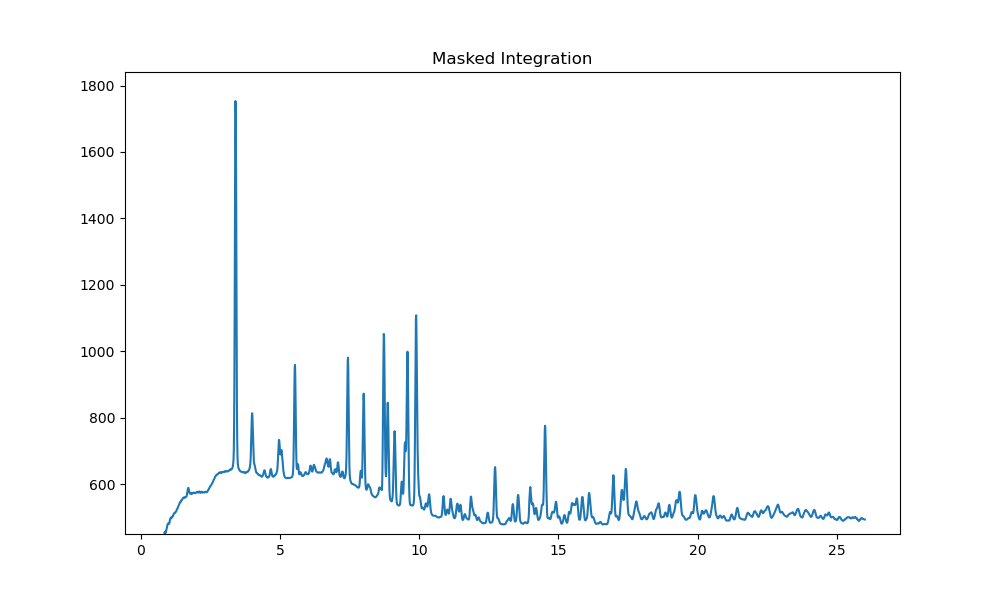

In [51]:
fig = plt.figure(figsize=(10,6))
plt.plot(*masked_integration)
plt.title('Masked Integration')
plt.ylim(bottom=450)
plt.show()

In [44]:
# feature_vector = np.hstack((spectral_entropy, acf))
# feature_vector = np.hstack((spectral_entropy, acf, sums, means_stds, means_median, num_peaks))
feature_vector = np.hstack((spectral_entropy, acf, means_stds, sums, intensities, num_peaks))
pca = PCA(n_components=2)
transformed_data = pca.fit_transform(feature_vector)

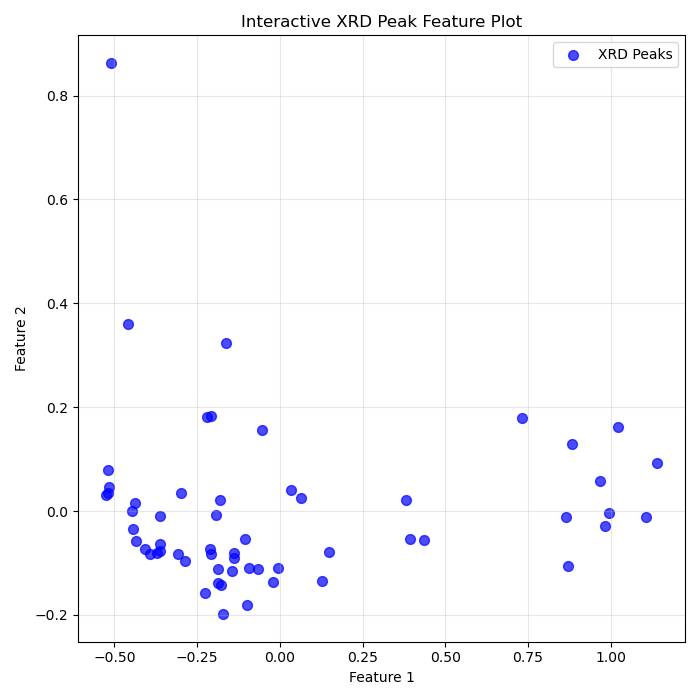

In [59]:
plot_interactive_peaks(peaks,peak_idxs,transformed_data,masked_integration[0])

In [91]:
peak_range = range(0,20)
masked_integration[0][peak_idxs][peak_range], masked_integration[1][peak_idxs][peak_range]
# masked_integration[0][peak_idxs][20:45]

(array([1.71706012, 3.40710033, 4.0041804 , 4.44946046, 4.68222049,
        4.96558052, 5.54242059, 6.09902066, 6.22046068, 6.67586073,
        6.79730075, 7.08066078, 7.44498083, 7.91050088, 8.0117009 ,
        8.73022098, 8.871901  , 9.11478103, 9.37790106, 9.48922108]),
 array([ 588.7621 , 1753.153  ,  813.53284,  641.88696,  645.3838 ,
         733.06836,  959.09216,  655.9011 ,  658.141  ,  677.4762 ,
         675.2511 ,  665.77466,  980.86975,  640.31415,  872.5601 ,
        1052.1895 ,  845.1181 ,  759.5269 ,  607.7778 ,  725.71124],
       dtype=float32))

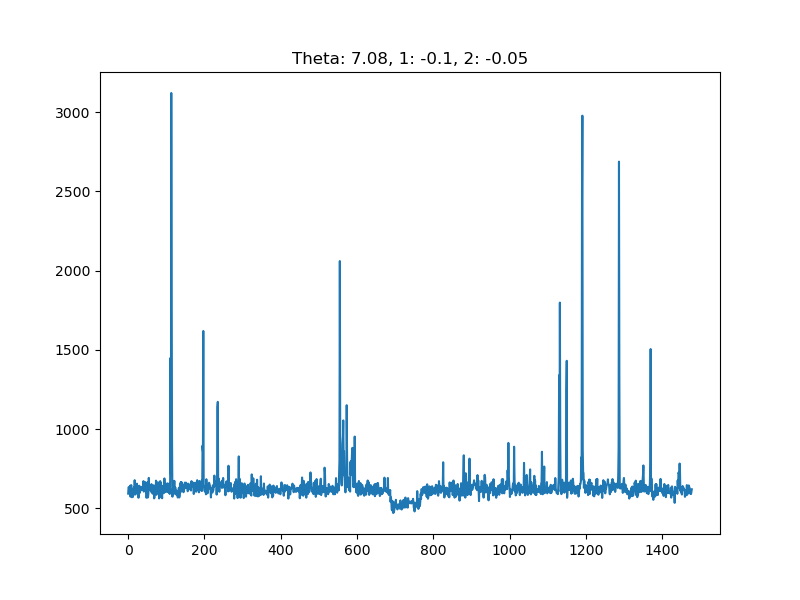

In [94]:
theta_to_plot =  7.081
peak_thetas = masked_integration[0][peak_idxs]

idx = np.argmin(np.abs(theta_to_plot - peak_thetas))

ring_to_plot = peak_azimuthal_rings[idx]
ring_to_plot = ring_to_plot[ring_to_plot != 0]
new_fig = plt.figure(figsize=(8, 6))
plt.plot(np.arange(len(ring_to_plot)), ring_to_plot)
plt.title(f'Theta: {round(masked_integration[0][peak_idxs[idx]],2)}, 1: {round(transformed_data[idx,0],2)}, 2: {round(transformed_data[idx,1],2)}')
plt.show()

### Plotting with labels

#### Plotting Function

In [402]:
scatter_labels = {'A': [7.17, 7.7, 8.99, 10.07, 18.78, 10.9, 11.81, 14.31, 17.53, 20.36],
                  'B': [6.28, 7.01, 10.49, 15.29, 15.62, 18.09, 21.21, 21.83],
                  'C': [4.14, 5.79, 6.12, 8.01, 9.83, 12.23, 12.75]}

def plot_interactive_peaks_with_labels(peak_list, peak_idx, feature_list, theta_array, 
                                        scatter_labels, tolerance=0.1):
    """
    Create an interactive scatter plot of peak features with color-coded labels.
    
    Parameters:
    - peak_list: List of peak intensities (same length as peak_idx and feature_list)
    - peak_idx: List of indices into theta_array (same length as peak_list and feature_list)
    - feature_list: List of 2D features for each peak (shape: N x 2)
    - theta_array: Full 2-theta array that peak_idx indexes into
    - scatter_labels: Dict mapping labels to lists of theta values
                     e.g., {'A': [7.17, 7.7, ...], 'B': [...], ...}
    - tolerance: Maximum difference in theta to consider a match (default: 0.1)
    """
    
    # Convert to numpy arrays
    peak_list = np.array(peak_list)
    peak_idx = np.array(peak_idx)
    feature_list = np.array(feature_list)
    theta_array = np.array(theta_array)
    
    # Get theta values for all peaks
    theta_values = theta_array[peak_idx]
    
    # Assign labels and colors to each point
    point_labels = ['Unlabeled'] * len(theta_values)
    
    # Create a color map for labels
    unique_labels = list(scatter_labels.keys())
    colors_map = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    label_to_color = {label: colors_map[i] for i, label in enumerate(unique_labels)}
    label_to_color['Unlabeled'] = 'lightgray'
    
    # Match theta values to labels
    for i, theta_val in enumerate(theta_values):
        for label, theta_list in scatter_labels.items():
            # Check if this theta is close to any in the label's list
            if any(abs(theta_val - labeled_theta) < tolerance for labeled_theta in theta_list):
                point_labels[i] = label
                break
    
    # Assign colors based on labels
    point_colors = [label_to_color[label] for label in point_labels]
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(8,6))
    
    # Plot each label group separately for proper legend
    for label in unique_labels + ['Unlabeled']:
        mask = np.array(point_labels) == label
        if np.any(mask):
            ax.scatter(
                feature_list[mask, 0], 
                feature_list[mask, 1],
                c=[label_to_color[label]],
                alpha=0.7,
                s=100 if label != 'Unlabeled' else 50,  # larger markers for labeled points
                label=f'{label} (n={np.sum(mask)})',
                edgecolors='black' if label != 'Unlabeled' else 'none',
                linewidths=1 if label != 'Unlabeled' else 0
            )
    
    # Set labels and title
    ax.set_xlabel('PCA Component 1', fontsize=12)
    ax.set_ylabel('PCA Component 2', fontsize=12)
    ax.set_title('XRD Peak Feature Plot with Labels', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', framealpha=0.9)
    
    # Create interactive cursor
    scatter_all = ax.scatter(
        feature_list[:, 0], 
        feature_list[:, 1],
        c=point_colors,
        alpha=0.7,
        s=100,
        edgecolors='black',
        linewidths=1,
        picker=True  # Enable picking
    )
    # Remove the extra scatter plot from legend (we already have labeled ones)
    scatter_all.set_label('_nolegend_')
    
    # Refresh legend to exclude scatter_all
    ax.legend(loc='best', framealpha=0.9)
    
    cursor = mplcursors.cursor(scatter_all, hover=True)
    
    @cursor.connect("add")
    def on_add(sel):
        # Get the clicked point coordinates
        x, y = sel.target
        
        # Find the closest point in feature space
        distances = np.sum((feature_list - np.array([x, y]))**2, axis=1)
        point_idx = np.argmin(distances)
        
        # Get the corresponding theta value, intensity, and label
        theta_value = theta_values[point_idx]
        intensity_value = peak_list[point_idx]
        label = point_labels[point_idx]
        
        # Set the tooltip text
        sel.annotation.set_text(
            f'Peak {point_idx}\n'
            f'Label: {label}\n'
            f'2θ: {theta_value:.3f}°\n'
            f'Intensity: {intensity_value:.1f}'
        )
        
        # Set annotation background color to match point color
        sel.annotation.get_bbox_patch().set_facecolor(label_to_color[label])
        sel.annotation.get_bbox_patch().set_alpha(0.8)
        
        # Print to console
        print(f"Selected peak {point_idx}: Label={label}, 2θ={theta_value:.3f}°, I={intensity_value:.1f}")
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n=== Labeling Summary ===")
    for label in unique_labels + ['Unlabeled']:
        count = point_labels.count(label)
        print(f"{label}: {count} peaks")
    
    return point_labels

#### Actual plotting labelled scatter plot

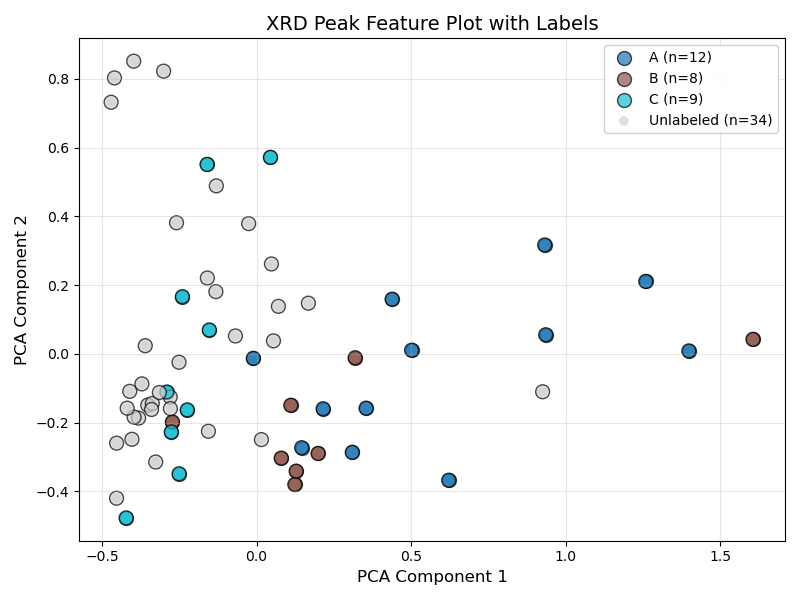


=== Labeling Summary ===
A: 12 peaks
B: 8 peaks
C: 9 peaks
Unlabeled: 34 peaks


['Unlabeled',
 'C',
 'C',
 'Unlabeled',
 'C',
 'C',
 'B',
 'B',
 'A',
 'A',
 'C',
 'Unlabeled',
 'A',
 'Unlabeled',
 'Unlabeled',
 'C',
 'A',
 'A',
 'B',
 'Unlabeled',
 'A',
 'Unlabeled',
 'A',
 'Unlabeled',
 'C',
 'Unlabeled',
 'Unlabeled',
 'C',
 'C',
 'Unlabeled',
 'Unlabeled',
 'Unlabeled',
 'A',
 'B',
 'B',
 'Unlabeled',
 'Unlabeled',
 'Unlabeled',
 'A',
 'B',
 'Unlabeled',
 'A',
 'A',
 'Unlabeled',
 'Unlabeled',
 'A',
 'Unlabeled',
 'B',
 'B',
 'Unlabeled',
 'Unlabeled',
 'Unlabeled',
 'Unlabeled',
 'Unlabeled',
 'Unlabeled',
 'Unlabeled',
 'Unlabeled',
 'Unlabeled',
 'Unlabeled',
 'Unlabeled',
 'Unlabeled',
 'Unlabeled',
 'Unlabeled']

In [403]:
peak_thetas = masked_integration[0][peak_idxs]

plot_interactive_peaks_with_labels(peaks, peak_idxs, transformed_data, masked_integration[0],
                                   scatter_labels)


## Looking at FFTs to see any inspiration

In [193]:
#Computing FFT
window_size = 1
cnv_azim_rings = []
for vec in azimuthal_rings:
    if len(vec) > 0:
        cnv_azim_rings.append(np.convolve(vec,np.ones(window_size)/window_size, mode = 'valid'))

fft_azim_rings = []
for vec in cnv_azim_rings:
    vec_max = np.max(vec)
    vec_median = np.median(vec)
    vec[vec >= 0.95*vec_max] = vec_median
    fft_vec = np.fft.fft(vec)
    fft_vec_norm = fft_vec/np.sum(fft_vec)
    fft_azim_rings.append(fft_vec_norm)




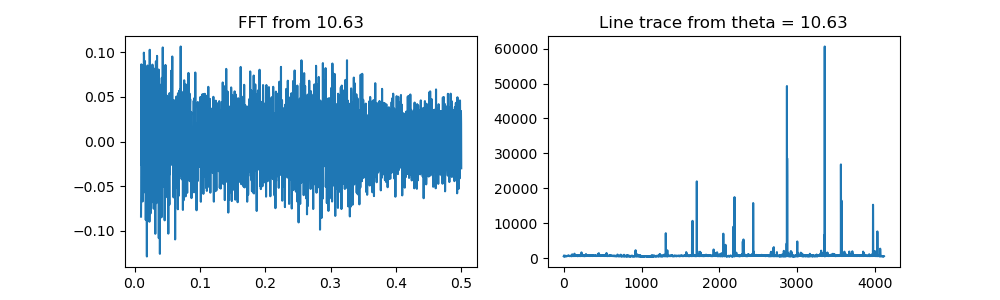

In [194]:
plt.ioff()
angle = 10.62 #in theta degree units
theta_val = np.linspace(np.min(mask.TA),
                            np.max(mask.TA),
                            n_theta_bins)
i = (np.abs(theta_val - angle)).argmin()

#First plot
y_plt = np.fft.fftshift(fft_azim_rings[i])
freqs = np.fft.fftfreq(len(y_plt), 1)
x_plt = np.fft.fftshift(freqs)
x_plt_i = (np.abs(x_plt - 0.01)).argmin()
#Second plot
y_plt_1 = cnv_azim_rings[i]
x_plt_1 = np.arange(len(y_plt_1))
#Entropy calc
spec_entropy, high_spec_entropy = _calculate_spectral_entropy_single(cnv_azim_rings[i])

fig, axs = plt.subplots(1,2,figsize=(10,3))

axs[0].plot(x_plt[x_plt_i:],y_plt[x_plt_i:])
axs[1].plot(x_plt_1,y_plt_1)
# axs[1].set_ylim([0, 3000])
# axs[2].plot(*masked_integration)

# axs[0].set_title(f'Approximate FFT from: {round(theta_val[i],2)} with entropy {round(spec_entropy,2)} and high freq. entropy {round(-np.log(high_spec_entropy),2)}')
axs[0].set_title(f'FFT from {round(theta_val[i],2)}')
axs[1].set_title(f'Line trace from theta = {round(theta_val[i],2)}')
plt.show()

## Spectral Entropies below (fixed outliers screwing up entropy)

In [174]:
entropies = fast_spectral_entropy(azimuthal_rings)
# bins, hist_vals = fast_spectra_binning(azimuthal_rings)

ValueError: zero-size array to reduction operation maximum which has no identity

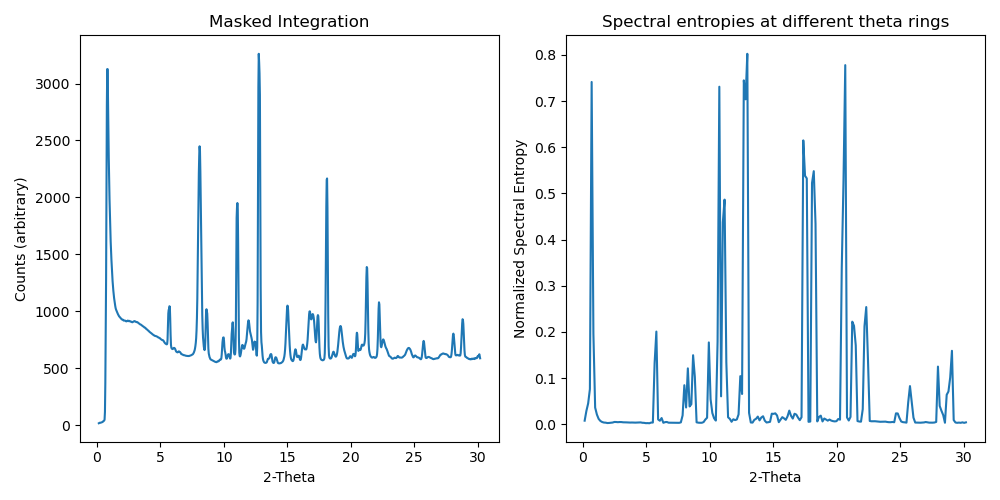

In [63]:
theta_val = np.linspace(np.min(mask.TA),
                            np.max(mask.TA),
                            n_theta_bins)[1:]

# Turn off interactive mode for this cell
# plt.ioff()

# Create a single figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Original theta plot
ax[0].plot(*masked_integration)
ax[0].set_xlabel('2-Theta')
ax[0].set_ylabel('Counts (arbitrary)')
ax[0].set_title('Masked Integration')

# Entropies
ax[1].plot(theta_val, entropies)
ax[1].set_xlabel('2-Theta')
ax[1].set_ylabel('Normalized Spectral Entropy')
ax[1].set_title('Spectral entropies at different theta rings')

# Improve layout
plt.tight_layout()

# Render the plot
plt.show()



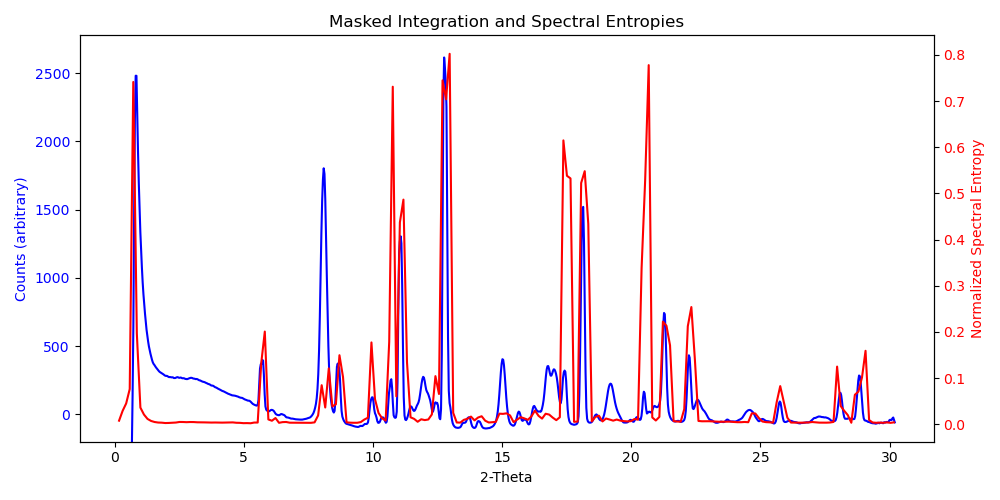

In [64]:
#Same sided plot

# Turn off interactive mode for this cell
# plt.ion()

# Create a single figure with one plot (instead of subplots)
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot masked integration on the left y-axis
ax1.plot(masked_integration[0], masked_integration[1] - np.median(masked_integration[1]), color='blue')
ax1.set_xlabel('2-Theta')
ax1.set_ylabel('Counts (arbitrary)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_ylim(bottom=-200)

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()

# Plot entropies on the right y-axis
ax2.plot(theta_val, entropies, color='red')
ax2.set_ylabel('Normalized Spectral Entropy', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add a title
plt.title('Masked Integration and Spectral Entropies')

# Improve layout
fig.tight_layout()

# Render the plot
plt.show()

Going to calculate intensities of each ring then just do a 2d scatter

In [ ]:
#Convert list of arrays into 2d array
np_avgd_intensities = []
acf_entropies = []
window_size = 10

for i, array in enumerate(azimuthal_rings):
    np_avgd_intensities.append(np.sum(azimuthal_rings[i])/(len(azimuthal_rings[i])+1))

    #ACF
    time_series = azimuthal_rings[i]
    cnv_time_series = np.convolve(time_series, np.ones(window_size)/window_size, mode='valid')
    acf_entropies.append(calculate_acf_entropy(cnv_time_series,max_lag=40))



In [76]:
intensity_range = np.max(np_avgd_intensities) - np.min(np_avgd_intensities)
entropy_range = np.max(entropies) - np.min(entropies)

intensity_range, entropy_range

(2601.442028985507, 0.800152338667813)

In [77]:
np.max(acf_entropies)

nan

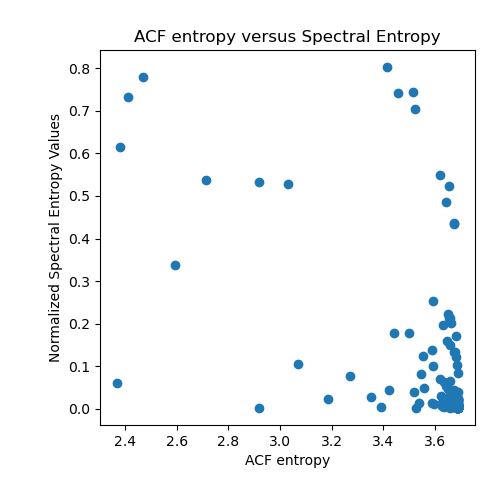

In [78]:
plot_acf_entropies = acf_entropies[1:-1]
plot_entropies = entropies[1:-1]

# Normalize the distance calculation
# Get the range of each dimension
intensity_range = np.max(np_avgd_intensities) - np.min(np_avgd_intensities)
acf_range = np.max(plot_acf_entropies) - np.min(plot_acf_entropies)
entropy_range = np.max(plot_entropies) - np.min(plot_entropies)

plt.ion()

fig = plt.figure(figsize=(5,5))
ax = fig.add_axes([0.2, 0.15, 0.75, 0.75])
im1 = plt.scatter(plot_acf_entropies,plot_entropies)
# plt.xlim(left=600)

plt.xlabel('ACF entropy')
plt.ylabel('Normalized Spectral Entropy Values')
plt.title('ACF entropy versus Spectral Entropy')

# Make plots interactive
cursor1 = mplcursors.cursor(im1)
@cursor1.connect("add")
def on_add(sel):
    # Get the index by finding the closest point
    x, y = sel.target
    # Calculate normalized distances
    norm_x_diff = (plot_acf_entropies - x) / acf_range
    norm_y_diff = (plot_entropies - y) / entropy_range
    distances = (norm_x_diff)**2 + (norm_y_diff)**2
    idx = np.argmin(distances)
    
    # Set the annotation text to show the index
    sel.annotation.set_text(f'Index: {idx}, Theta: {round(theta_val[idx],2)}')
    sel.annotation.set(ha="left")
    sel.annotation.xy_offset = (15, 0)  # Move tooltip to the right
    print(f"Selected point index: {idx}")#theta_val[idx]

# cursor1.annotation_kwargs["ha"] = "left"  # "ha" is horizontal alignment
# cursor1.annotation_kwargs["xytext"] = (15, 0)  # Offset tooltip to the right of the cursor

plt.show()


# Looking at auto-correlation function instead

In [82]:
from statsmodels.tsa.stattools import acf

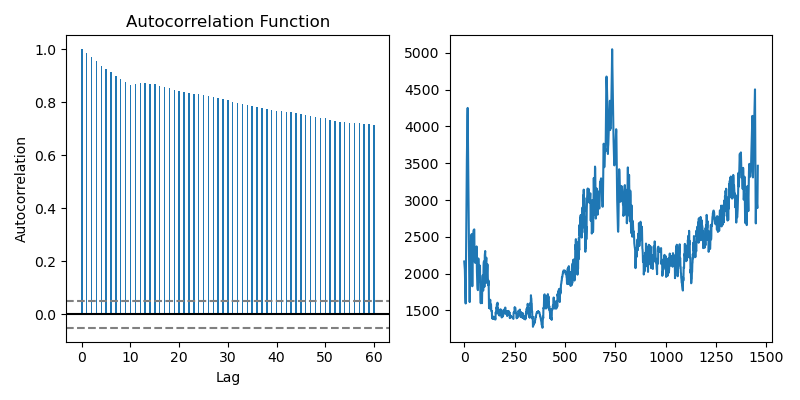

Entropy is 4.091302440335843


In [83]:
angle = 5.8773 #in theta degree units
theta_val = np.linspace(np.min(mask.TA),
                            np.max(mask.TA),
                            n_theta_bins)
i = (np.abs(theta_val - angle)).argmin()
window_size = 10
time_series = azimuthal_rings[i]
cnv_time_series = np.convolve(time_series, np.ones(window_size)/window_size, mode='valid')

acf_values = acf(cnv_time_series, nlags=60, fft = True)

# Plot the autocorrelation function
fig, axs = plt.subplots(1,2,figsize=(8, 4))

axs[0].bar(range(len(acf_values)), acf_values, width=0.3)
axs[0].axhline(y=0, linestyle='-', color='black')
axs[0].axhline(y=-1.96/np.sqrt(len(time_series)), linestyle='--', color='gray')
axs[0].axhline(y=1.96/np.sqrt(len(time_series)), linestyle='--', color='gray')
axs[0].set_xlabel('Lag')
axs[0].set_ylabel('Autocorrelation')
axs[0].set_title('Autocorrelation Function')

axs[1].plot(np.arange(0,len(cnv_time_series)), cnv_time_series)




plt.tight_layout()
plt.show()

print(f"Entropy is {calculate_acf_entropy(cnv_time_series,max_lag=60)}")

# PCA of different combinations

In [84]:
from sklearn.decomposition import PCA

In [ ]:
#Convert list of arrays into 2d array
np_avgd_intensities = []
acf_entropies = []
window_size = 10

for i, array in enumerate(azimuthal_rings[1:-1]):
    np_avgd_intensities.append(np.sum(azimuthal_rings[i])/(len(azimuthal_rings[i])+1))

    #ACF
    # time_series = azimuthal_rings[i]
    # cnv_time_series = np.convolve(time_series, np.ones(window_size)/window_size, mode='valid')
    # acf_entropies.append(calculate_acf_entropy(cnv_time_series,max_lag=40))

ValueError: v cannot be empty

In [85]:
#Going to try PCA of normalized intensities, entropy and acf_entropy
#Rescale everything

#Doing 1:-1 because acf entropies do not calculate at first and last element

pca_avgd_intensities = np_avgd_intensities[1:-1]
pca_acf_entropies = acf_entropies[1:-1]
pca_entropies = entropies[1:-1]

# Normalize the distance calculation
# Get the range of each dimension
acf_range = np.max(pca_acf_entropies) - np.min(pca_acf_entropies)

#Rescale intensities and acf
np_avgd_int_rescaled = pca_avgd_intensities/(np.max(pca_avgd_intensities) - np.min(pca_avgd_intensities))
acf_entropies_rescaled = pca_acf_entropies/(acf_range)

feature_vector = np.stack([acf_entropies_rescaled, pca_entropies,np_avgd_int_rescaled]).transpose()

# Apply PCA
pca = PCA(n_components=3)
transformed_data = pca.fit_transform(feature_vector)


NameError: name 'np_avgd_intensities' is not defined

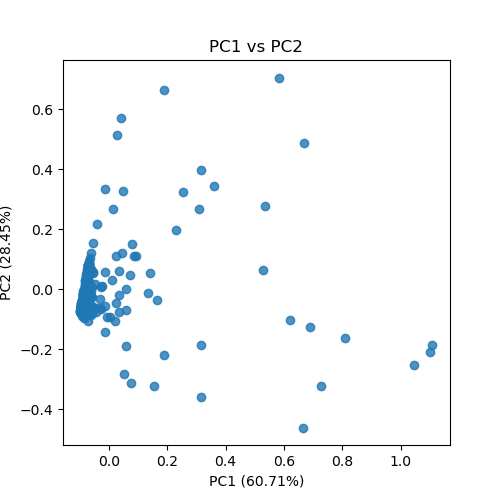

In [88]:
fig = plt.figure(figsize=(5,5))

scatter = plt.scatter(transformed_data[:, 0], transformed_data[:, 1], alpha=0.8)

plt.title('PC1 vs PC2')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')

# Add interactive cursor
cursor = mplcursors.cursor(scatter, hover=False)  # 'hover=False' means click is required

@cursor.connect("add")
def on_add(sel):
    # Get the x, y coordinates of the selected point
    x, y = sel.target
    
    # Calculate distances to find the closest point
    distances = np.sqrt((transformed_data[:, 0] - x)**2 + (transformed_data[:, 1] - y)**2)
    idx = np.argmin(distances)
       
    # Set the annotation text to show the index
    sel.annotation.set_text(f'Index: {idx}\nTheta: {theta_val[idx]}')
    
    # Optional: Print additional info to console
    print(f"Selected point index: {idx}")
    print(f"PCA coordinates: {transformed_data[idx]}")

plt.show()